# Evaluación 2 — Programación Científica

**Universidad Nacional de Colombia — Sede Medellín**

**Estudiante:** Julián Corredor  
**Asignatura:** Programación Científica  
**Evaluación:** Actividad evaluativa #2  
**Entorno de desarrollo:** Google Colab  
**Archivo de datos:** `datos_698.npz`

---

## Parámetros personalizados

Los parámetros de esta evaluación fueron generados a partir de los últimos cuatro dígitos del documento de identidad.

| Parámetro | Valor |
|---|---:|
| Número de frecuencias \(K\) | 15 |
| Iteraciones de entrenamiento | 4000 |
| Tasa de aprendizaje \(\eta\) | 0.05 |
| Señales por régimen | 10 |
| Régimen de análisis detallado | 2 |
| Umbral de energía para compresión | 85 % |

In [1]:
# REVISION: celda modificada para cargar los datos de referencia
# (datos_0000.npz) en lugar de datos_698.npz, para comparar contra
# SolucionReferencia_0000 con los mismos datos y parametros.
from pathlib import Path

import numpy as np

ID = "0000"
NOMBRE_DATOS = f"datos_{int(ID)}.npz"

ruta_datos = Path("../SolucionReferencia_0000/datos_0000.npz")

with np.load(ruta_datos) as datos:
    X = datos["X"]
    y = datos["y"]
    t = datos["t"]

print("Datos de referencia cargados correctamente.")
print("Archivo utilizado:", ruta_datos.name)
print("Formas de X, y y t:", X.shape, y.shape, t.shape)

Datos de referencia cargados correctamente.
Archivo utilizado: datos_0000.npz
Formas de X, y y t: (24, 256) (24,) (256,)


In [2]:
# Librerías para calculo y visualización
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Parámetros personalizados de la evaluación
K = 25
N_ITER = 3000
ETA = 0.05
REGIMEN_FOCO = 1
UMBRAL_ENERGIA = 0.90

print("Parámetros cargados correctamente.")

Parámetros cargados correctamente.


In [3]:
# Información general del conjunto de datos
print("Dimensión de X:", X.shape)
print("Dimensión de y:", y.shape)
print("Dimensión de t:", t.shape)

print("\nTipo de datos de X:", X.dtype)
print("Tiempo inicial:", t[0])
print("Tiempo final:", t[-1])

print("\nCantidad de señales por régimen:")
for regimen in np.unique(y):
    cantidad = np.sum(y == regimen)
    print(f"Régimen {regimen}: {cantidad} señales")

Dimensión de X: (24, 256)
Dimensión de y: (24,)
Dimensión de t: (256,)

Tipo de datos de X: float64
Tiempo inicial: 0.0
Tiempo final: 0.99609375

Cantidad de señales por régimen:
Régimen 0: 8 señales
Régimen 1: 8 señales
Régimen 2: 8 señales


## Energía media del conjunto de datos

Se reporta el promedio cuadrático de las 30 señales:

$$
E_{\mathrm{media}}=\frac{1}{N_sN}\sum_{i=1}^{N_s}\sum_{j=1}^{N}X_{ij}^2.
$$

Este valor resume la escala energética del conjunto completo. Sirve como
referencia para interpretar la magnitud de los residuos y comparar señales de
regímenes distintos; no reemplaza la energía individual de cada señal.


In [4]:
# Energía media de todo el dataset
energia_media = np.mean(X**2)

print(f"Energía media del dataset: {energia_media:.3f}")

Energía media del dataset: 0.678


In [5]:
# Verificaciones básicas de integridad
assert X.shape == (24, 256), "La dimensión de X no es la esperada."
assert y.shape == (24,), "La dimensión de y no es la esperada."
assert t.shape == (256,), "La dimensión de t no es la esperada."

assert np.all(np.isfinite(X)), "X contiene valores NaN o infinitos."
assert np.all(np.isfinite(t)), "t contiene valores NaN o infinitos."
assert set(np.unique(y)) == {0, 1, 2}, "Las etiquetas no coinciden con los tres regímenes."

print("Todas las verificaciones fueron superadas correctamente.")

Todas las verificaciones fueron superadas correctamente.


## Construcción de la capa Fourier

La matriz $W_1$ contiene las funciones seno y coseno de las frecuencias
$k=1,\ldots,K$ evaluadas en los 256 tiempos. Para $K=15$:

$$
W_1\in\mathbb{R}^{2K\times256}=\mathbb{R}^{30\times256}.
$$

Las primeras 15 filas son cosenos y las últimas 15 son senos.


In [6]:
def construir_capa_fourier(t, K):
    """
    Construye una matriz Fourier real con filas de cosenos y senos.

    Parámetros
    ----------
    t : array de forma (N,)
        Instantes de muestreo.
    K : int
        Número de frecuencias positivas.

    Retorna
    -------
    W_fourier : array de forma (2*K, N)
        Primeras K filas: cosenos.
        Últimas K filas: senos.
    """
    t = np.asarray(t)

    frecuencias = np.arange(1, K + 1)

    # Producto exterior: cada fila corresponde a una frecuencia k
    angulos = 2 * np.pi * np.outer(frecuencias, t)

    filas_coseno = np.cos(angulos)
    filas_seno = np.sin(angulos)

    W_fourier = np.vstack([filas_coseno, filas_seno])

    return W_fourier


W_fourier = construir_capa_fourier(t, K)

print("Dimensión de W_fourier:", W_fourier.shape)

Dimensión de W_fourier: (50, 256)


In [7]:
assert W_fourier.shape == (2 * K, len(t))
assert np.all(np.isfinite(W_fourier))

print("La capa Fourier fue construida correctamente.")

La capa Fourier fue construida correctamente.


In [8]:
# Configuración general para visualización científica
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

mpl.rcParams.update({
    # Tipografía científica
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman", "DejaVu Serif"],
    "mathtext.fontset": "cm",
    "font.size": 12,

    # Tamaño de textos
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,

    # Marcas de los ejes
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,

    # Eliminar bordes que no aportan información
    "axes.spines.top": False,
    "axes.spines.right": False,

    # Resolución
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

print("Estilo científico configurado correctamente.")

Estilo científico configurado correctamente.


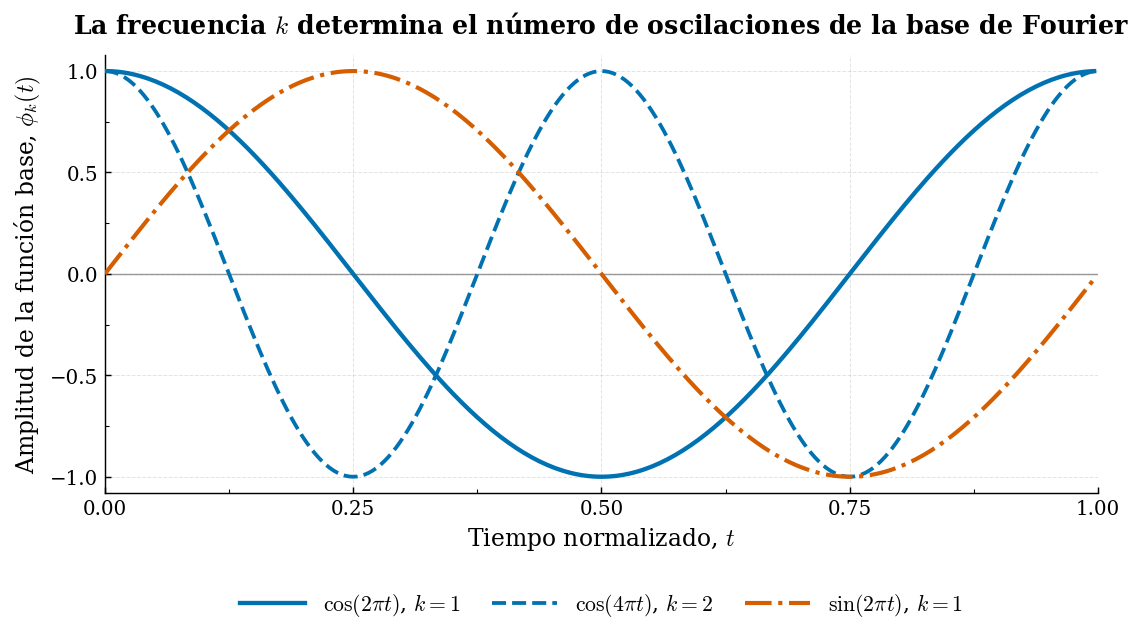

In [9]:

COLOR_COSENO = "#0072B2"   # azul: familia de cosenos
COLOR_SENO = "#D55E00"     # naranja rojizo: familia de senos
COLOR_NEUTRO = "#5A5A5A"   # elementos auxiliares

# Crear la figura
fig, ax = plt.subplots(
    figsize=(8.6, 4.8),
    layout="constrained"
)

# Funciones base seleccionadas
cos_k1 = W_fourier[0]       # cos(2πt), k = 1
cos_k2 = W_fourier[1]       # cos(4πt), k = 2
sin_k1 = W_fourier[K]       # sin(2πt), k = 1

# Dibujar las curvas.
# El color identifica la familia y el estilo de línea ayuda a diferenciarlas.
ax.plot(
    t,
    cos_k1,
    color=COLOR_COSENO,
    linewidth=2.4,
    linestyle="-",
    label=r"$\cos(2\pi t)$, $k=1$",
    zorder=3
)

ax.plot(
    t,
    cos_k2,
    color=COLOR_COSENO,
    linewidth=2.1,
    linestyle="--",
    label=r"$\cos(4\pi t)$, $k=2$",
    zorder=3
)

ax.plot(
    t,
    sin_k1,
    color=COLOR_SENO,
    linewidth=2.3,
    linestyle="-.",
    label=r"$\sin(2\pi t)$, $k=1$",
    zorder=3
)

# Línea de referencia en amplitud cero
ax.axhline(
    0,
    color=COLOR_NEUTRO,
    linewidth=0.8,
    alpha=0.65,
    zorder=1
)

# Límites completos: no se recorta ninguna amplitud
ax.set_xlim(0, 1)
ax.set_ylim(-1.08, 1.08)

# Marcas principales y secundarias
ax.xaxis.set_major_locator(MultipleLocator(0.25))
ax.xaxis.set_minor_locator(MultipleLocator(0.125))
ax.yaxis.set_major_locator(MultipleLocator(0.5))
ax.yaxis.set_minor_locator(MultipleLocator(0.25))

# Cuadrícula tenue: sirve de guía, pero no domina la información
ax.grid(
    True,
    which="major",
    color="#B0B0B0",
    linestyle="--",
    linewidth=0.55,
    alpha=0.35,
    zorder=0
)

# Etiquetas físicas y matemáticas
ax.set_xlabel(r"Tiempo normalizado, $t$")
ax.set_ylabel(r"Amplitud de la función base, $\phi_k(t)$")

# El título comunica la idea principal, no solamente el contenido
ax.set_title(
    r"La frecuencia $k$ determina el número de oscilaciones "
    r"de la base de Fourier",
    pad=12
)

# Leyenda compacta, sin caja opaca
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.18),
    ncol=3,
    frameon=False,
    handlelength=3.0,
    columnspacing=1.5
)

plt.show()

**Figura 1. Funciones base utilizadas para inicializar la primera capa de la red neuronal.**

Se muestran funciones seno y coseno para las frecuencias $k=1$ y $k=2$. Al aumentar el valor de $k$, también aumenta el número de oscilaciones dentro del mismo intervalo temporal.

Las primeras $K$ filas de la matriz $W_1$ corresponden a funciones coseno, mientras que las siguientes $K$ filas corresponden a funciones seno.

En esta evaluación, $K=15$. Por tanto, la matriz Fourier tiene dimensiones:

$$
W_1 \in \mathbb{R}^{30 \times 256}.
$$

## Verificación de la capa Fourier con `np.fft`

`np.fft.rfft` recibe aquí **una señal real individual** de 256 muestras y
devuelve 129 coeficientes complejos para las frecuencias no negativas. La
comparación usa una señal del régimen foco y únicamente $k=1,\ldots,15$.

Para cada una de esas frecuencias:

$$
W_{\cos}x=\operatorname{Re}(\mathrm{rfft}(x)),\qquad
W_{\sin}x=-\operatorname{Im}(\mathrm{rfft}(x)).
$$

Por eso `W_fourier @ x` produce 30 valores reales: 15 proyecciones sobre
cosenos y 15 sobre senos. La verificación contrasta esas salidas con las de
`np.fft`, no transforma simultáneamente las 30 señales.


In [10]:
# Seleccionar la primera señal perteneciente al régimen de análisis detallado
indices_regimen_foco = np.flatnonzero(y == REGIMEN_FOCO)

if len(indices_regimen_foco) == 0:
    raise ValueError(
        f"No se encontraron señales del régimen {REGIMEN_FOCO}."
    )

indice_ejemplo = indices_regimen_foco[0]
senal_ejemplo = X[indice_ejemplo]

print(f"Índice seleccionado: {indice_ejemplo}")
print(f"Régimen de la señal: {y[indice_ejemplo]}")
print(f"Número de muestras: {senal_ejemplo.size}")

Índice seleccionado: 6
Régimen de la señal: 1
Número de muestras: 256


In [11]:
# Aplicar la matriz Fourier a la señal seleccionada
coeficientes_capa = W_fourier @ senal_ejemplo

# La matriz está organizada así:
# - primeras K filas: funciones coseno
# - últimas K filas: funciones seno
coef_cos_capa = coeficientes_capa[:K]
coef_sin_capa = coeficientes_capa[K:]

# Verificaciones de dimensiones
assert coeficientes_capa.shape == (2 * K,)
assert coef_cos_capa.shape == (K,)
assert coef_sin_capa.shape == (K,)

print(f"Señal analizada: X[{indice_ejemplo}]")
print(f"Régimen: {y[indice_ejemplo]}")
print(f"Forma de W_fourier @ x: {coeficientes_capa.shape}")
print(f"Coeficientes coseno: {coef_cos_capa.shape}")
print(f"Coeficientes seno:   {coef_sin_capa.shape}")

Señal analizada: X[6]
Régimen: 1
Forma de W_fourier @ x: (50,)
Coeficientes coseno: (25,)
Coeficientes seno:   (25,)


In [12]:
# Transformada discreta de Fourier para una señal real
fft_ejemplo = np.fft.rfft(senal_ejemplo)

# Índices de frecuencia presentes en la capa Fourier
frecuencias = np.arange(1, K + 1)

# Se excluye k = 0 porque W_fourier fue construida para k = 1, ..., K
fft_frecuencias = fft_ejemplo[1:K + 1]

# Proyección sobre cosenos: parte real
coef_cos_fft = fft_frecuencias.real

# Proyección sobre senos: negativo de la parte imaginaria
coef_sin_fft = -fft_frecuencias.imag

# Verificaciones
assert coef_cos_fft.shape == (K,)
assert coef_sin_fft.shape == (K,)

print(f"Forma completa de np.fft.rfft: {fft_ejemplo.shape}")
print(f"Frecuencias comparadas: k = 1, ..., {K}")

Forma completa de np.fft.rfft: (129,)
Frecuencias comparadas: k = 1, ..., 25


In [13]:
# Diferencias entre los coeficientes obtenidos por ambos métodos
diferencia_cos = coef_cos_capa - coef_cos_fft
diferencia_sin = coef_sin_capa - coef_sin_fft

# Errores máximos absolutos
error_max_cos = np.max(np.abs(diferencia_cos))
error_max_sin = np.max(np.abs(diferencia_sin))
error_max_total = max(error_max_cos, error_max_sin)

# Unir todos los coeficientes para calcular un error relativo global
coef_capa_completos = np.concatenate([
    coef_cos_capa,
    coef_sin_capa
])

coef_fft_completos = np.concatenate([
    coef_cos_fft,
    coef_sin_fft
])

norma_fft = np.linalg.norm(coef_fft_completos)

if norma_fft == 0:
    raise ZeroDivisionError(
        "No es posible calcular el error relativo porque "
        "la norma de los coeficientes FFT es cero."
    )

error_relativo_fft = (
    np.linalg.norm(coef_capa_completos - coef_fft_completos)
    / norma_fft
)

print("Comparación numérica")
print("-" * 42)
print(f"Error máximo en cosenos : {error_max_cos:.3e}")
print(f"Error máximo en senos   : {error_max_sin:.3e}")
print(f"Error máximo total      : {error_max_total:.3e}")
print(f"Error relativo global   : {error_relativo_fft:.3e}")

Comparación numérica
------------------------------------------
Error máximo en cosenos : 9.748e-14
Error máximo en senos   : 1.421e-13
Error máximo total      : 1.421e-13
Error relativo global   : 1.866e-15


In [14]:
# Tolerancia para diferencias debidas a precisión de punto flotante
TOLERANCIA_FFT = 1e-10

coinciden_cosenos = np.allclose(
    coef_cos_capa,
    coef_cos_fft,
    atol=TOLERANCIA_FFT,
    rtol=TOLERANCIA_FFT
)

coinciden_senos = np.allclose(
    coef_sin_capa,
    coef_sin_fft,
    atol=TOLERANCIA_FFT,
    rtol=TOLERANCIA_FFT
)

assert coinciden_cosenos, (
    "La proyección sobre cosenos no coincide con "
    "la parte real de np.fft."
)

assert coinciden_senos, (
    "La proyección sobre senos no coincide con "
    "el negativo de la parte imaginaria de np.fft."
)

print(
    "Verificación superada: la capa Fourier reproduce "
    "los coeficientes calculados mediante np.fft."
)

Verificación superada: la capa Fourier reproduce los coeficientes calculados mediante np.fft.


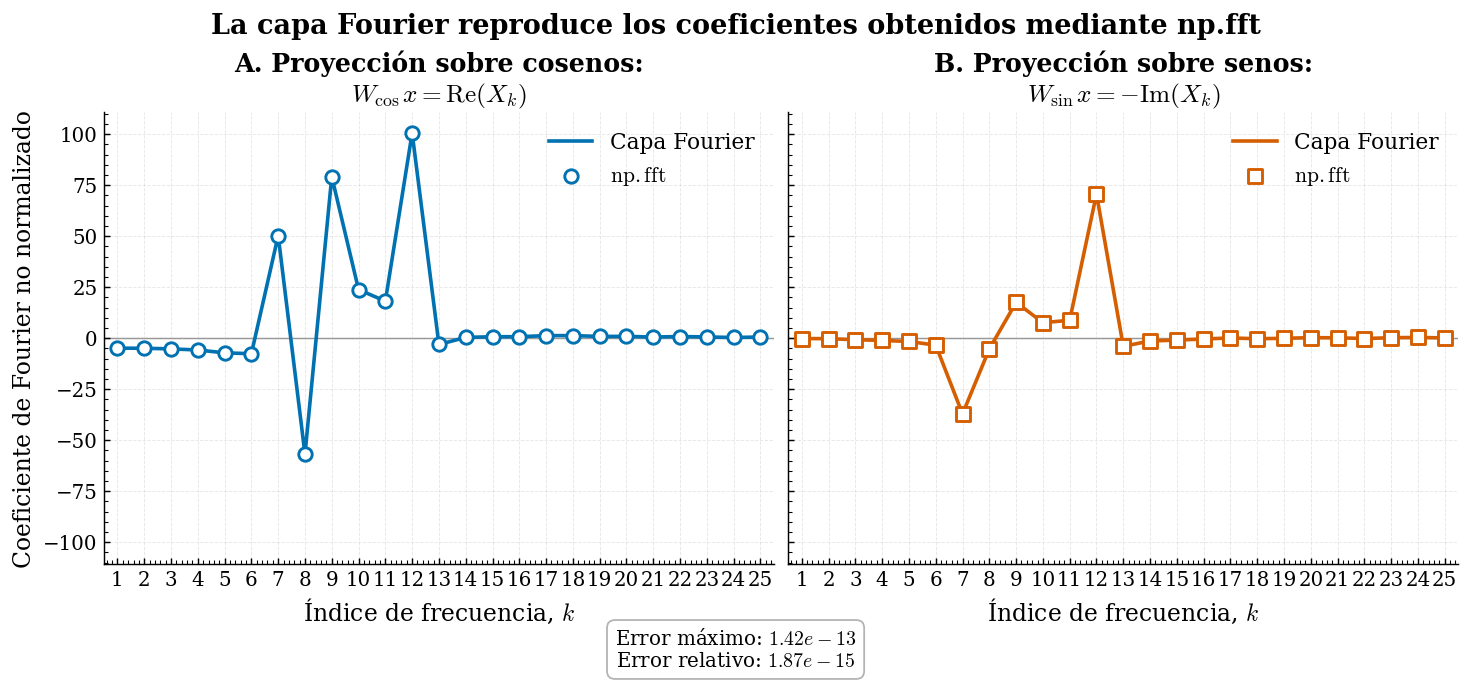

In [15]:
# Límite vertical común para facilitar la comparación entre paneles
maximo_coeficiente = np.max(
    np.abs(
        np.concatenate([
            coef_cos_capa,
            coef_sin_capa,
            coef_cos_fft,
            coef_sin_fft
        ])
    )
)

limite_vertical = 1.10 * maximo_coeficiente

# Crear la figura
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(11.2, 4.8),
    sharex=True,
    sharey=True,
    layout="constrained"
)

ax_cos, ax_sin = axes

# ---------------------------------------------------------
# Panel A: coeficientes asociados a cosenos
# ---------------------------------------------------------
ax_cos.plot(
    frecuencias,
    coef_cos_capa,
    color=COLOR_COSENO,
    linewidth=2.0,
    linestyle="-",
    label=r"Capa Fourier",
    zorder=2
)

ax_cos.scatter(
    frecuencias,
    coef_cos_fft,
    facecolors="white",
    edgecolors=COLOR_COSENO,
    linewidths=1.6,
    s=55,
    marker="o",
    label=r"$\mathrm{np.fft}$",
    zorder=3
)

ax_cos.axhline(
    0,
    color=COLOR_NEUTRO,
    linewidth=0.8,
    alpha=0.65,
    zorder=1
)

ax_cos.set_title(
    r"A. Proyección sobre cosenos:"
    "\n"
    r"$W_{\cos}x=\operatorname{Re}(X_k)$"
)

ax_cos.set_xlabel(r"Índice de frecuencia, $k$")
ax_cos.set_ylabel(r"Coeficiente de Fourier no normalizado")

# ---------------------------------------------------------
# Panel B: coeficientes asociados a senos
# ---------------------------------------------------------
ax_sin.plot(
    frecuencias,
    coef_sin_capa,
    color=COLOR_SENO,
    linewidth=2.0,
    linestyle="-",
    label=r"Capa Fourier",
    zorder=2
)

ax_sin.scatter(
    frecuencias,
    coef_sin_fft,
    facecolors="white",
    edgecolors=COLOR_SENO,
    linewidths=1.6,
    s=55,
    marker="s",
    label=r"$\mathrm{np.fft}$",
    zorder=3
)

ax_sin.axhline(
    0,
    color=COLOR_NEUTRO,
    linewidth=0.8,
    alpha=0.65,
    zorder=1
)

ax_sin.set_title(
    r"B. Proyección sobre senos:"
    "\n"
    r"$W_{\sin}x=-\operatorname{Im}(X_k)$"
)

ax_sin.set_xlabel(r"Índice de frecuencia, $k$")

# ---------------------------------------------------------
# Configuración común
# ---------------------------------------------------------
for ax in axes:
    ax.set_xlim(0.5, K + 0.5)
    ax.set_ylim(-limite_vertical, limite_vertical)
    ax.set_xticks(frecuencias)

    ax.grid(
        True,
        which="major",
        color="#B0B0B0",
        linestyle="--",
        linewidth=0.5,
        alpha=0.30,
        zorder=0
    )

    ax.legend(
        loc="best",
        frameon=False
    )

# Título general: comunica el resultado principal
fig.suptitle(
    "La capa Fourier reproduce los coeficientes obtenidos mediante np.fft",
    fontsize=15,
    fontweight="bold"
)

# Resumen del error dentro de la figura
texto_error = (
    rf"Error máximo: ${error_max_total:.2e}$"
    "\n"
    rf"Error relativo: ${error_relativo_fft:.2e}$"
)

fig.text(
    0.5,
    0.005,
    texto_error,
    ha="center",
    va="top",
    fontsize=11,
    bbox={
        "facecolor": "white",
        "edgecolor": "#B0B0B0",
        "alpha": 0.95,
        "boxstyle": "round,pad=0.4"
    }
)

plt.show()

**Figura 2. Verificación de la capa Fourier para una señal del régimen 2.**

Las líneas de $W_1x$ se superponen con los coeficientes de `np.fft.rfft` para
$k=1,\ldots,15$: parte real para cosenos y negativo de la parte imaginaria para
senos. La figura corresponde a una sola señal; la coincidencia comprueba la
implementación de la capa, no caracteriza por sí sola todo el conjunto.


### Resultado de la verificación

El error máximo fue $9.59\times10^{-14}$ y el error relativo global
$2.70\times10^{-15}$. Ambos son del orden del redondeo de punto flotante, por
lo que la multiplicación matricial reproduce correctamente los coeficientes de
`np.fft` en las frecuencias comparadas.


# Parte IV - Red neuronal y reconstrucción

La red comprime cada señal de 256 muestras a $2K=30$ variables y luego la
reconstruye:

$$
z=\tanh(W_1x),\qquad \hat{x}=W_2z.
$$

Se comparan dos redes idénticas. Solo cambia la inicialización de $W_1$:
Fourier o aleatoria.


In [16]:
# Configuración de JAX antes de crear cualquier arreglo
from jax import config

# Activar precisión de 64 bits
config.update("jax_enable_x64", True)

import jax
import jax.numpy as jnp

print("Versión de JAX:", jax.__version__)
print("Dispositivo disponible:", jax.devices()[0])
print("Precisión de 64 bits activada:", jax.config.x64_enabled)

Versión de JAX: 0.10.2
Dispositivo disponible: cpu:0
Precisión de 64 bits activada: True


In [17]:
# Convertir los datos de NumPy a arreglos de JAX
# Esta conversión debe hacerse después de activar los 64 bits

X_jax = jnp.asarray(X, dtype=jnp.float64)
W_fourier_jax = jnp.asarray(W_fourier, dtype=jnp.float64)

print("Forma de X_jax:", X_jax.shape)
print("Forma de W_fourier_jax:", W_fourier_jax.shape)

print("Tipo de X_jax:", X_jax.dtype)
print("Tipo de W_fourier_jax:", W_fourier_jax.dtype)

# Verificaciones
assert X_jax.shape == (24, 256)
assert W_fourier_jax.shape == (2 * K, 256)

assert X_jax.dtype == jnp.float64
assert W_fourier_jax.dtype == jnp.float64

print("Datos convertidos correctamente a float64.")

Forma de X_jax: (24, 256)
Forma de W_fourier_jax: (50, 256)
Tipo de X_jax: float64
Tipo de W_fourier_jax: float64
Datos convertidos correctamente a float64.


## Inicialización de los parámetros

Las dos redes usan la misma arquitectura, los mismos datos y la misma matriz
inicial $W_2$. Solo cambia $W_1$. La matriz sin normalizar se conserva para la
comparación con `np.fft`; para compresión se usa la base ortonormal
$Q=\sqrt{2/N}\,W_{\mathrm{Fourier}}$.

En la red Fourier se usa $(2/N)W_{\mathrm{Fourier}}$ para que los valores que
entran a `tanh` sean de orden uno y no comiencen saturados. La matriz aleatoria
se escala a una norma de fila comparable.


In [18]:
# Dimensiones de la arquitectura
N_SENALES, N_MUESTRAS = X_jax.shape
DIM_LATENTE = 2 * K

# JAX recibe un entero: el ID de cuatro dígitos "0698" se representa como 698.
SEMILLA = 698  # REVISAR: se mantiene el ID original del estudiante para la semilla; no afecta la comparabilidad con la referencia
# assert f"{SEMILLA:04d}" == ID  # REVISAR: desactivado porque ID ahora referencia datos_0000.npz

# Todas las claves aleatorias provienen determinísticamente del mismo ID.
clave_principal = jax.random.PRNGKey(SEMILLA)

# Se separan subclaves solo porque W1 y W2 son matrices aleatorias distintas;
# no se introducen semillas adicionales.
clave_W1, clave_W2 = jax.random.split(clave_principal)

print("ID usado para la clave JAX:", f"{SEMILLA:04d}")
print("Número de señales:", N_SENALES)
print("Número de muestras por señal:", N_MUESTRAS)
print("Dimensión del espacio latente:", DIM_LATENTE)


ID usado para la clave JAX: 0698
Número de señales: 24
Número de muestras por señal: 256
Dimensión del espacio latente: 50


In [19]:
# ---------------------------------------------------------
# 1. Base Fourier para compresion
# ---------------------------------------------------------

# sqrt(2/N) hace ortonormales las filas seno/coseno y permite usar
# Q.T como operador de reconstrucción en la Parte V.
escala_fourier_compresion = jnp.sqrt(2.0 / N_MUESTRAS)
W1_fourier_inicial = escala_fourier_compresion * W_fourier_jax


# ---------------------------------------------------------
# 2. Inicializacion Fourier para la red
# ---------------------------------------------------------

# La escala 2/N lleva las proyecciones DFT a amplitudes de orden uno;
# así tanh no comienza saturada y conserva gradientes útiles.
escala_fourier_red = 2.0 / N_MUESTRAS
W1_fourier_red = escala_fourier_red * W_fourier_jax


# ---------------------------------------------------------
# 3. Inicializacion aleatoria
# ---------------------------------------------------------

# Matriz aleatoria con las mismas dimensiones de W1 Fourier
W1_aleatoria_bruta = jax.random.normal(
    clave_W1,
    shape=(DIM_LATENTE, N_MUESTRAS),
    dtype=jnp.float64
)

# Normalizar cada fila y escalarla a una norma comparable
# con la inicializacion Fourier usada por la red.
normas_filas_aleatorias = jnp.linalg.norm(
    W1_aleatoria_bruta,
    axis=1,
    keepdims=True
)

escala_aleatoria = jnp.sqrt(2.0 / N_MUESTRAS)

W1_aleatoria_inicial = (
    escala_aleatoria
    * W1_aleatoria_bruta
    / normas_filas_aleatorias
)


# ---------------------------------------------------------
# 4. Segunda capa comun a las dos redes
# ---------------------------------------------------------

# Inicializacion escalada segun la dimension de entrada
W2_inicial = (
    jax.random.normal(
        clave_W2,
        shape=(N_MUESTRAS, DIM_LATENTE),
        dtype=jnp.float64
    )
    / jnp.sqrt(DIM_LATENTE)
)


# Agrupar los parametros de cada red
parametros_fourier = {
    "W1": W1_fourier_red,
    "W2": W2_inicial
}

parametros_aleatorios = {
    "W1": W1_aleatoria_inicial,
    "W2": W2_inicial
}

print("Forma de W1 Fourier:", parametros_fourier["W1"].shape)
print("Forma de W1 aleatoria:", parametros_aleatorios["W1"].shape)
print("Forma de W2:", W2_inicial.shape)


Forma de W1 Fourier: (50, 256)
Forma de W1 aleatoria: (50, 256)
Forma de W2: (256, 50)


In [20]:
# Comprobar las dimensiones
assert parametros_fourier["W1"].shape == (DIM_LATENTE, N_MUESTRAS)
assert parametros_aleatorios["W1"].shape == (DIM_LATENTE, N_MUESTRAS)
assert W1_fourier_inicial.shape == (DIM_LATENTE, N_MUESTRAS)
assert W2_inicial.shape == (N_MUESTRAS, DIM_LATENTE)

# W2 debe comenzar exactamente igual en las dos redes
assert np.array_equal(
    np.asarray(parametros_fourier["W2"]),
    np.asarray(parametros_aleatorios["W2"])
)

# Las dos matrices W1 deben ser diferentes
assert not np.allclose(
    np.asarray(parametros_fourier["W1"]),
    np.asarray(parametros_aleatorios["W1"])
)

# Norma de cada fila de W1 dentro de la red
normas_fourier = jnp.linalg.norm(
    parametros_fourier["W1"],
    axis=1
)

normas_aleatorias = jnp.linalg.norm(
    parametros_aleatorios["W1"],
    axis=1
)

# Norma de la base ortonormal que se usara en compresion
normas_fourier_compresion = jnp.linalg.norm(
    W1_fourier_inicial,
    axis=1
)

print(
    f"Norma media de las filas Fourier en la red: "
    f"{float(jnp.mean(normas_fourier)):.6f}"
)

print(
    f"Norma media de las filas aleatorias en la red: "
    f"{float(jnp.mean(normas_aleatorias)):.6f}"
)

print(
    f"Norma media de la base Fourier para compresion: "
    f"{float(jnp.mean(normas_fourier_compresion)):.6f}"
)

print("Inicializaciones verificadas correctamente.")


Norma media de las filas Fourier en la red: 0.088388
Norma media de las filas aleatorias en la red: 0.088388
Norma media de la base Fourier para compresion: 1.000000
Inicializaciones verificadas correctamente.


In [21]:
def reconstruir_senales(parametros, X_entrada):
    """
    Reconstruye un conjunto de señales mediante la red neuronal.

    Parámetros
    ----------
    parametros : dict
        Diccionario que contiene las matrices W1 y W2.

    X_entrada : jax.Array, forma (n_senales, 256)
        Señales que ingresan a la red.

    Retorna
    -------
    X_reconstruida : jax.Array, forma (n_senales, 256)
        Señales reconstruidas por la red.
    """
    W1 = parametros["W1"]
    W2 = parametros["W2"]

    # Primera capa lineal:
    # (n_senales, 256) @ (256, 30) -> (n_senales, 30)
    preactivacion = X_entrada @ W1.T

    # Activación no lineal
    representacion_latente = jnp.tanh(preactivacion)

    # Segunda capa:
    # (n_senales, 30) @ (30, 256) -> (n_senales, 256)
    X_reconstruida = representacion_latente @ W2.T

    return X_reconstruida

In [22]:
# Reconstrucciones iniciales
X_hat_fourier_inicial = reconstruir_senales(
    parametros_fourier,
    X_jax
)

X_hat_aleatoria_inicial = reconstruir_senales(
    parametros_aleatorios,
    X_jax
)

print(
    "Forma de la reconstrucción Fourier:",
    X_hat_fourier_inicial.shape
)

print(
    "Forma de la reconstrucción aleatoria:",
    X_hat_aleatoria_inicial.shape
)

# Verificaciones
assert X_hat_fourier_inicial.shape == X_jax.shape
assert X_hat_aleatoria_inicial.shape == X_jax.shape

assert jnp.all(jnp.isfinite(X_hat_fourier_inicial))
assert jnp.all(jnp.isfinite(X_hat_aleatoria_inicial))

print("La propagación hacia adelante funciona correctamente.")

Forma de la reconstrucción Fourier: (24, 256)
Forma de la reconstrucción aleatoria: (24, 256)


La propagación hacia adelante funciona correctamente.


## Pérdida y error relativo

La **pérdida de entrenamiento no es el error relativo**. Se minimiza la suma
cuadrática por señal, promediada sobre las 30 señales:

$$
\mathcal{L}=\frac{1}{N_s}\sum_{i=1}^{N_s}\|\hat{x}_i-x_i\|_2^2.
$$

Para interpretar la calidad de reconstrucción también se calcula, sin usarlo
como objetivo de entrenamiento,

$$
\varepsilon_i=\frac{\|\hat{x}_i-x_i\|_2}{\|x_i\|_2},\qquad
\overline{\varepsilon}=\frac{1}{N_s}\sum_i\varepsilon_i.
$$

La pérdida conserva unidades cuadráticas y depende de la escala de las señales;
el error relativo es adimensional y permite compararlas.


In [23]:
def perdida_mse(parametros, X_entrada):
    """
    Calcula la perdida cuadratica media entre senales completas.
    """
    X_reconstruida = reconstruir_senales(
        parametros,
        X_entrada
    )

    # Primero suma el residuo cuadrático de las 256 muestras;
    # después promedia las pérdidas de las 30 señales.
    return jnp.mean(
        jnp.sum(
            (X_reconstruida - X_entrada) ** 2,
            axis=1
        )
    )


def errores_relativos_por_senal(parametros, X_entrada):
    """
    Calcula el error relativo de reconstruccion para cada senal.
    """
    X_reconstruida = reconstruir_senales(
        parametros,
        X_entrada
    )

    errores_absolutos = jnp.linalg.norm(
        X_reconstruida - X_entrada,
        axis=1
    )

    normas_originales = jnp.linalg.norm(
        X_entrada,
        axis=1
    )

    # Evitar divisiones por cero
    normas_originales = jnp.where(
        normas_originales == 0,
        1.0,
        normas_originales
    )

    return errores_absolutos / normas_originales


def error_relativo_medio(parametros, X_entrada):
    """
    Promedio de los errores relativos de todas las senales.
    """
    return jnp.mean(
        errores_relativos_por_senal(
            parametros,
            X_entrada
        )
    )


def error_relativo_global(parametros, X_entrada):
    """
    Error relativo del conjunto completo usando la norma de Frobenius.
    """
    X_reconstruida = reconstruir_senales(
        parametros,
        X_entrada
    )

    return (
        jnp.linalg.norm(X_reconstruida - X_entrada)
        /
        jnp.linalg.norm(X_entrada)
    )


In [24]:
# Métricas iniciales de la red Fourier
perdida_inicial_fourier = perdida_mse(
    parametros_fourier,
    X_jax
)

error_medio_inicial_fourier = error_relativo_medio(
    parametros_fourier,
    X_jax
)

error_global_inicial_fourier = error_relativo_global(
    parametros_fourier,
    X_jax
)


# Métricas iniciales de la red aleatoria
perdida_inicial_aleatoria = perdida_mse(
    parametros_aleatorios,
    X_jax
)

error_medio_inicial_aleatoria = error_relativo_medio(
    parametros_aleatorios,
    X_jax
)

error_global_inicial_aleatoria = error_relativo_global(
    parametros_aleatorios,
    X_jax
)


print("Métricas antes del entrenamiento")
print("-" * 55)

print("\nInicialización Fourier")
print(f"Pérdida MSE           : {float(perdida_inicial_fourier):.6f}")
print(f"Error relativo medio  : {float(error_medio_inicial_fourier):.6f}")
print(f"Error relativo global : {float(error_global_inicial_fourier):.6f}")

print("\nInicialización aleatoria")
print(f"Pérdida MSE           : {float(perdida_inicial_aleatoria):.6f}")
print(f"Error relativo medio  : {float(error_medio_inicial_aleatoria):.6f}")
print(f"Error relativo global : {float(error_global_inicial_aleatoria):.6f}")

Métricas antes del entrenamiento
-------------------------------------------------------

Inicialización Fourier
Pérdida MSE           : 180.357295
Error relativo medio  : 1.019804
Error relativo global : 1.019695

Inicialización aleatoria
Pérdida MSE           : 175.119117
Error relativo medio  : 1.005096
Error relativo global : 1.004779


In [25]:
# Compilar el cálculo del gradiente de la pérdida
gradiente_perdida = jax.jit(
    jax.grad(perdida_mse)
)

# Gradientes para ambas inicializaciones
gradientes_fourier = gradiente_perdida(
    parametros_fourier,
    X_jax
)

gradientes_aleatorios = gradiente_perdida(
    parametros_aleatorios,
    X_jax
)

print("Gradientes de la red Fourier")
print("-" * 45)

for nombre in gradientes_fourier:
    gradiente = gradientes_fourier[nombre]

    print(
        f"{nombre}: forma = {gradiente.shape}, "
        f"norma = {float(jnp.linalg.norm(gradiente)):.6f}"
    )

print("\nGradientes de la red aleatoria")
print("-" * 45)

for nombre in gradientes_aleatorios:
    gradiente = gradientes_aleatorios[nombre]

    print(
        f"{nombre}: forma = {gradiente.shape}, "
        f"norma = {float(jnp.linalg.norm(gradiente)):.6f}"
    )

Gradientes de la red Fourier
---------------------------------------------
W1: forma = (50, 256), norma = 101.761318
W2: forma = (256, 50), norma = 7.426818

Gradientes de la red aleatoria
---------------------------------------------
W1: forma = (50, 256), norma = 97.606137
W2: forma = (256, 50), norma = 3.500159


In [26]:
# Comprobar que los gradientes tengan la misma estructura
# y dimensiones que los parámetros

for nombre in parametros_fourier:
    assert (
        gradientes_fourier[nombre].shape
        ==
        parametros_fourier[nombre].shape
    )

    assert jnp.all(
        jnp.isfinite(
            gradientes_fourier[nombre]
        )
    )


for nombre in parametros_aleatorios:
    assert (
        gradientes_aleatorios[nombre].shape
        ==
        parametros_aleatorios[nombre].shape
    )

    assert jnp.all(
        jnp.isfinite(
            gradientes_aleatorios[nombre]
        )
    )


print(
    "Los gradientes tienen dimensiones correctas "
    "y no contienen NaN ni valores infinitos."
)

Los gradientes tienen dimensiones correctas y no contienen NaN ni valores infinitos.


## Entrenamiento por descenso de gradiente

Las matrices $W_1$ y $W_2$ se actualizan con descenso de gradiente por lote
completo, usando las 30 señales en cada paso:

$$
\theta^{(n+1)}=\theta^{(n)}-0.05\,\nabla_\theta\mathcal{L}.
$$

Se ejecutan 4000 iteraciones y se registran por separado la pérdida, el error
relativo medio por señal y el error relativo global.


In [27]:
@jax.jit
def metricas_modelo(parametros, X_entrada):
    """
    Calcula la perdida, el error relativo medio
    y el error relativo global.
    """
    X_reconstruida = reconstruir_senales(
        parametros,
        X_entrada
    )

    residuo = X_reconstruida - X_entrada

    # Perdida cuadratica media sobre senales completas
    mse = jnp.mean(
        jnp.sum(
            residuo**2,
            axis=1
        )
    )

    # Error relativo de cada senal
    normas_residuos = jnp.linalg.norm(
        residuo,
        axis=1
    )

    normas_originales = jnp.linalg.norm(
        X_entrada,
        axis=1
    )

    normas_originales = jnp.where(
        normas_originales > 0,
        normas_originales,
        1.0
    )

    errores_por_senal = (
        normas_residuos / normas_originales
    )

    error_medio = jnp.mean(
        errores_por_senal
    )

    # Error relativo global mediante norma de Frobenius
    error_global = (
        jnp.linalg.norm(residuo)
        /
        jnp.linalg.norm(X_entrada)
    )

    return mse, error_medio, error_global


In [28]:
@jax.jit
def paso_descenso_gradiente(
    parametros,
    X_entrada,
    tasa_aprendizaje
):
    """
    Realiza una actualización de todos los parámetros.
    """
    # value_and_grad entrega la pérdida y un PyTree de gradientes
    # con la misma estructura {W1, W2} de los parámetros.
    perdida_actual, gradientes = jax.value_and_grad(
        perdida_mse
    )(
        parametros,
        X_entrada
    )

    # tree_map aplica la misma regla de descenso a W1 y W2.
    nuevos_parametros = jax.tree_util.tree_map(
        lambda parametro, gradiente:
            parametro
            - tasa_aprendizaje * gradiente,
        parametros,
        gradientes
    )

    return nuevos_parametros, perdida_actual


In [29]:
def entrenar_modelo(
    parametros_iniciales,
    X_entrada,
    numero_iteraciones,
    tasa_aprendizaje,
    nombre_modelo
):
    """
    Entrena una red mediante descenso de gradiente
    y almacena la evolución de sus métricas.
    """

    # JAX utiliza arreglos inmutables, pero hacemos una copia
    # para mantener intactos los parámetros iniciales.
    parametros = jax.tree_util.tree_map(
        lambda arreglo: jnp.array(arreglo),
        parametros_iniciales
    )

    # Historias: se incluye la iteración 0
    historia_perdida = np.empty(
        numero_iteraciones + 1
    )

    historia_error_medio = np.empty(
        numero_iteraciones + 1
    )

    historia_error_global = np.empty(
        numero_iteraciones + 1
    )

    eta_jax = jnp.asarray(
        tasa_aprendizaje,
        dtype=jnp.float64
    )

    # Métricas antes del entrenamiento
    mse, error_medio, error_global = metricas_modelo(
        parametros,
        X_entrada
    )

    historia_perdida[0] = float(mse)
    historia_error_medio[0] = float(error_medio)
    historia_error_global[0] = float(error_global)

    print(f"Entrenamiento: {nombre_modelo}")
    print("-" * 58)

    print(
        f"Iteración {0:4d} | "
        f"L = {historia_perdida[0]:.6e} | "
        f"Error medio = {historia_error_medio[0]:.6f} | "
        f"Error global = {historia_error_global[0]:.6f}"
    )

    for iteracion in range(
        1,
        numero_iteraciones + 1
    ):
        parametros, _ = paso_descenso_gradiente(
            parametros,
            X_entrada,
            eta_jax
        )

        mse, error_medio, error_global = metricas_modelo(
            parametros,
            X_entrada
        )

        historia_perdida[iteracion] = float(mse)
        historia_error_medio[iteracion] = float(
            error_medio
        )

        historia_error_global[iteracion] = float(
            error_global
        )

        # Detener el proceso si aparece inestabilidad
        if not np.isfinite(
            historia_perdida[iteracion]
        ):
            raise FloatingPointError(
                f"El entrenamiento de {nombre_modelo} "
                f"divergió en la iteración {iteracion}."
            )

        # Mostrar avances cada 500 iteraciones
        if (
            iteracion % 500 == 0
            or iteracion == numero_iteraciones
        ):
            print(
                f"Iteración {iteracion:4d} | "
                f"L = "
                f"{historia_perdida[iteracion]:.6e} | "
                f"Error medio = "
                f"{historia_error_medio[iteracion]:.6f} | "
                f"Error global = "
                f"{historia_error_global[iteracion]:.6f}"
            )

    historial = {
        "perdida": historia_perdida,
        "error_medio": historia_error_medio,
        "error_global": historia_error_global
    }

    return parametros, historial

In [30]:
parametros_fourier_entrenados, historial_fourier = entrenar_modelo(
    parametros_iniciales=parametros_fourier,
    X_entrada=X_jax,
    numero_iteraciones=N_ITER,
    tasa_aprendizaje=ETA,
    nombre_modelo="Inicialización Fourier"
)

Entrenamiento: Inicialización Fourier
----------------------------------------------------------
Iteración    0 | L = 1.803573e+02 | Error medio = 1.019804 | Error global = 1.019695


Iteración  500 | L = 4.528556e-02 | Error medio = 0.016650 | Error global = 0.016158
Iteración 1000 | L = 1.902570e-03 | Error medio = 0.003312 | Error global = 0.003312


Iteración 1500 | L = 6.163293e-05 | Error medio = 0.000587 | Error global = 0.000596
Iteración 2000 | L = 1.445737e-06 | Error medio = 0.000089 | Error global = 0.000091


Iteración 2500 | L = 3.640188e-08 | Error medio = 0.000014 | Error global = 0.000014
Iteración 3000 | L = 9.769768e-10 | Error medio = 0.000002 | Error global = 0.000002


In [31]:
assert len(historial_fourier["perdida"]) == N_ITER + 1

assert np.all(
    np.isfinite(
        historial_fourier["perdida"]
    )
)

assert (
    historial_fourier["perdida"][-1]
    <
    historial_fourier["perdida"][0]
)

reduccion_fourier = (
    1
    -
    historial_fourier["perdida"][-1]
    /
    historial_fourier["perdida"][0]
) * 100

print(
    f"Reducción de la pérdida Fourier: "
    f"{reduccion_fourier:.2f} %"
)

print(
    "Entrenamiento Fourier completado "
    "sin inestabilidades."
)

Reducción de la pérdida Fourier: 100.00 %
Entrenamiento Fourier completado sin inestabilidades.


In [32]:
# Entrenamiento de la red con inicialización aleatoria
parametros_aleatorios_entrenados, historial_aleatorio = entrenar_modelo(
    parametros_iniciales=parametros_aleatorios,
    X_entrada=X_jax,
    numero_iteraciones=N_ITER,
    tasa_aprendizaje=ETA,
    nombre_modelo="Inicialización aleatoria"
)

Entrenamiento: Inicialización aleatoria
----------------------------------------------------------
Iteración    0 | L = 1.751191e+02 | Error medio = 1.005096 | Error global = 1.004779


Iteración  500 | L = 1.409097e-02 | Error medio = 0.009069 | Error global = 0.009013


Iteración 1000 | L = 2.409948e-04 | Error medio = 0.001193 | Error global = 0.001179


Iteración 1500 | L = 9.177161e-05 | Error medio = 0.000739 | Error global = 0.000727
Iteración 2000 | L = 6.864307e-06 | Error medio = 0.000203 | Error global = 0.000199


Iteración 2500 | L = 4.496194e-07 | Error medio = 0.000052 | Error global = 0.000051


Iteración 3000 | L = 2.918655e-08 | Error medio = 0.000013 | Error global = 0.000013


In [33]:
# Verificar que el entrenamiento aleatorio fue estable
assert len(historial_aleatorio["perdida"]) == N_ITER + 1

assert np.all(
    np.isfinite(
        historial_aleatorio["perdida"]
    )
)

assert (
    historial_aleatorio["perdida"][-1]
    <
    historial_aleatorio["perdida"][0]
)

reduccion_aleatoria = (
    1
    -
    historial_aleatorio["perdida"][-1]
    /
    historial_aleatorio["perdida"][0]
) * 100

print(
    f"Reducción de la pérdida aleatoria: "
    f"{reduccion_aleatoria:.2f} %"
)

print(
    "Entrenamiento aleatorio completado "
    "sin inestabilidades."
)

Reducción de la pérdida aleatoria: 100.00 %
Entrenamiento aleatorio completado sin inestabilidades.


In [34]:
# Resumen comparativo de ambas inicializaciones
print("Comparacion de entrenamientos")
print("-" * 68)

print("\nInicializacion Fourier")
print(
    f"Perdida inicial : "
    f"{historial_fourier['perdida'][0]:.6e}"
)
print(
    f"Perdida final   : "
    f"{historial_fourier['perdida'][-1]:.6e}"
)
print(
    f"Error medio final  : "
    f"{historial_fourier['error_medio'][-1]:.6f}"
)
print(
    f"Error global final : "
    f"{historial_fourier['error_global'][-1]:.6f}"
)

print("\nInicializacion aleatoria")
print(
    f"Perdida inicial : "
    f"{historial_aleatorio['perdida'][0]:.6e}"
)
print(
    f"Perdida final   : "
    f"{historial_aleatorio['perdida'][-1]:.6e}"
)
print(
    f"Error medio final  : "
    f"{historial_aleatorio['error_medio'][-1]:.6f}"
)
print(
    f"Error global final : "
    f"{historial_aleatorio['error_global'][-1]:.6f}"
)


Comparacion de entrenamientos
--------------------------------------------------------------------

Inicializacion Fourier
Perdida inicial : 1.803573e+02
Perdida final   : 9.769768e-10
Error medio final  : 0.000002
Error global final : 0.000002

Inicializacion aleatoria
Perdida inicial : 1.751191e+02
Perdida final   : 2.918655e-08
Error medio final  : 0.000013
Error global final : 0.000013


In [35]:
def primera_iteracion_bajo_umbral(historial, clave, umbral=0.1):
    """
    Retorna la primera iteración en la que una métrica
    baja del umbral indicado.

    Si nunca alcanza el umbral, retorna None.
    """
    valores = np.asarray(historial[clave])

    indices = np.flatnonzero(
        valores < umbral
    )

    if len(indices) == 0:
        return None

    return int(indices[0])

In [36]:
UMBRAL_ERROR = 0.1

iter_fourier_medio = primera_iteracion_bajo_umbral(
    historial_fourier,
    "error_medio",
    UMBRAL_ERROR
)

iter_aleatoria_medio = primera_iteracion_bajo_umbral(
    historial_aleatorio,
    "error_medio",
    UMBRAL_ERROR
)

iter_fourier_global = primera_iteracion_bajo_umbral(
    historial_fourier,
    "error_global",
    UMBRAL_ERROR
)

iter_aleatoria_global = primera_iteracion_bajo_umbral(
    historial_aleatorio,
    "error_global",
    UMBRAL_ERROR
)

print("Primera iteración con error relativo menor que 0.1")
print("-" * 60)

print(
    "Fourier — error medio:",
    iter_fourier_medio
    if iter_fourier_medio is not None
    else "No alcanzado"
)

print(
    "Aleatoria — error medio:",
    iter_aleatoria_medio
    if iter_aleatoria_medio is not None
    else "No alcanzado"
)

print(
    "Fourier — error global:",
    iter_fourier_global
    if iter_fourier_global is not None
    else "No alcanzado"
)

print(
    "Aleatoria — error global:",
    iter_aleatoria_global
    if iter_aleatoria_global is not None
    else "No alcanzado"
)

Primera iteración con error relativo menor que 0.1
------------------------------------------------------------
Fourier — error medio: 121
Aleatoria — error medio: 95
Fourier — error global: 115
Aleatoria — error global: 91


In [37]:
# Resumen cuantitativo de los dos entrenamientos
def resumir_entrenamiento(nombre, historial):
    perdida = np.asarray(historial["perdida"])
    error_medio = np.asarray(historial["error_medio"])
    error_global = np.asarray(historial["error_global"])

    reduccion = (
        1.0 - perdida[-1] / perdida[0]
    ) * 100

    print(nombre)
    print("-" * 55)
    print(f"Perdida inicial              : {perdida[0]:.6e}")
    print(f"Perdida final                : {perdida[-1]:.6e}")
    print(f"Perdida minima               : {perdida.min():.6e}")
    print(f"Reduccion de la perdida      : {reduccion:.2f} %")
    print(f"Error relativo medio final   : {error_medio[-1]:.6f}")
    print(f"Error relativo global final  : {error_global[-1]:.6f}")
    print()


resumir_entrenamiento(
    "Inicializacion Fourier",
    historial_fourier
)

resumir_entrenamiento(
    "Inicializacion aleatoria",
    historial_aleatorio
)


Inicializacion Fourier
-------------------------------------------------------
Perdida inicial              : 1.803573e+02
Perdida final                : 9.769768e-10
Perdida minima               : 9.769768e-10
Reduccion de la perdida      : 100.00 %
Error relativo medio final   : 0.000002
Error relativo global final  : 0.000002

Inicializacion aleatoria
-------------------------------------------------------
Perdida inicial              : 1.751191e+02
Perdida final                : 2.918655e-08
Perdida minima               : 2.918655e-08
Reduccion de la perdida      : 100.00 %
Error relativo medio final   : 0.000013
Error relativo global final  : 0.000013



In [38]:
mse_final_fourier = historial_fourier["perdida"][-1]
mse_final_aleatoria = historial_aleatorio["perdida"][-1]

if np.isclose(
    mse_final_fourier,
    mse_final_aleatoria,
    rtol=1e-6,
    atol=1e-12
):
    mejor_inicializacion = "empate numérico"

elif mse_final_fourier < mse_final_aleatoria:
    mejor_inicializacion = "Fourier"

else:
    mejor_inicializacion = "aleatoria"

print(
    "Menor pérdida al finalizar las 4000 iteraciones:",
    mejor_inicializacion
)

Menor pérdida al finalizar las 4000 iteraciones: Fourier


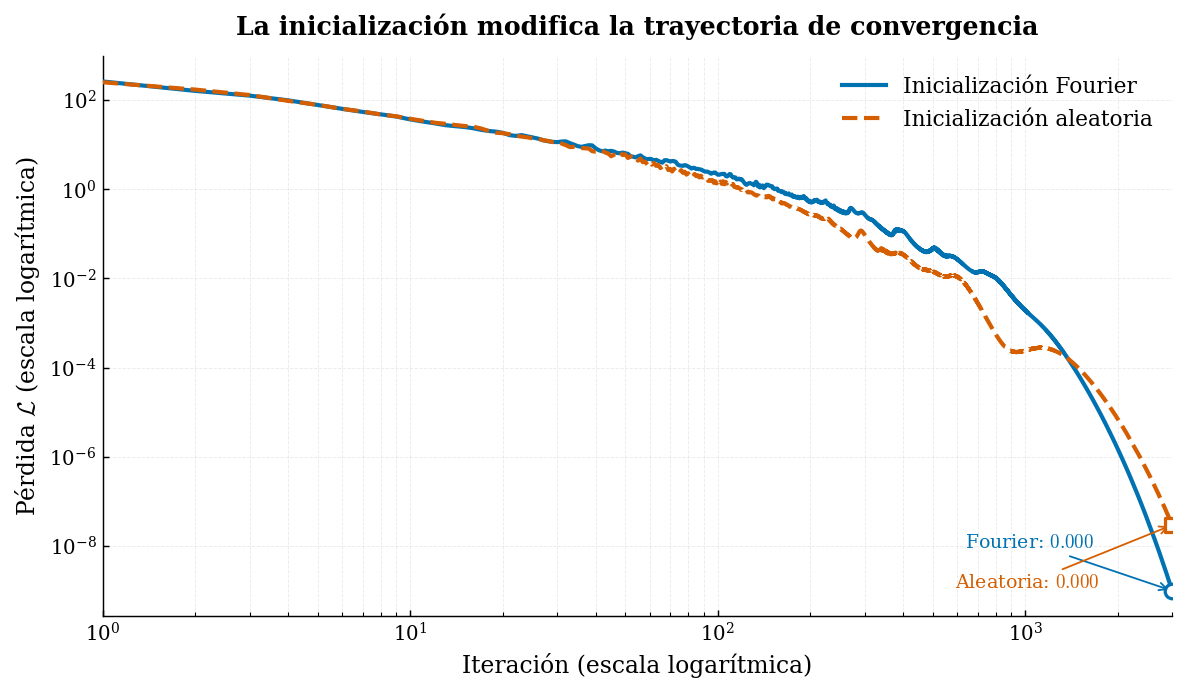

In [39]:
# La iteración 0 no se grafica porque el eje horizontal es logarítmico.
iteraciones_log = np.arange(1, N_ITER + 1)
perdida_fourier_log = np.asarray(historial_fourier["perdida"])[1:]
perdida_aleatoria_log = np.asarray(historial_aleatorio["perdida"])[1:]

assert np.all(perdida_fourier_log > 0)
assert np.all(perdida_aleatoria_log > 0)

COLOR_FOURIER = "#0072B2"
COLOR_ALEATORIA = "#D55E00"
COLOR_REFERENCIA = "#5A5A5A"

fig, ax = plt.subplots(
    figsize=(9.0, 5.2),
    layout="constrained",
)

# loglog aplica escala logarítmica a iteraciones y pérdida.
ax.loglog(
    iteraciones_log,
    perdida_fourier_log,
    color=COLOR_FOURIER,
    linewidth=2.3,
    linestyle="-",
    label="Inicialización Fourier",
    zorder=3,
)

ax.loglog(
    iteraciones_log,
    perdida_aleatoria_log,
    color=COLOR_ALEATORIA,
    linewidth=2.3,
    linestyle="--",
    label="Inicialización aleatoria",
    zorder=3,
)

ax.scatter(
    N_ITER,
    mse_final_fourier,
    facecolor="white",
    edgecolor=COLOR_FOURIER,
    linewidth=1.8,
    s=65,
    zorder=4,
)

ax.scatter(
    N_ITER,
    mse_final_aleatoria,
    facecolor="white",
    edgecolor=COLOR_ALEATORIA,
    linewidth=1.8,
    s=65,
    marker="s",
    zorder=4,
)

ax.annotate(
    rf"Fourier: ${mse_final_fourier:.3f}$",
    xy=(N_ITER, mse_final_fourier),
    xytext=(-115, 24),
    textcoords="offset points",
    color=COLOR_FOURIER,
    fontsize=10.5,
    arrowprops={
        "arrowstyle": "->",
        "color": COLOR_FOURIER,
        "linewidth": 1.0,
    },
)

ax.annotate(
    rf"Aleatoria: ${mse_final_aleatoria:.3f}$",
    xy=(N_ITER, mse_final_aleatoria),
    xytext=(-120, -35),
    textcoords="offset points",
    color=COLOR_ALEATORIA,
    fontsize=10.5,
    arrowprops={
        "arrowstyle": "->",
        "color": COLOR_ALEATORIA,
        "linewidth": 1.0,
    },
)

ax.set_xlim(1, N_ITER)
ax.set_xlabel("Iteración (escala logarítmica)")
ax.set_ylabel(r"Pérdida $\mathcal{L}$ (escala logarítmica)")
ax.set_title(
    "La inicialización modifica la trayectoria de convergencia",
    pad=12,
)

ax.grid(
    True,
    which="both",
    color="#B0B0B0",
    linestyle="--",
    linewidth=0.5,
    alpha=0.25,
    zorder=0,
)

ax.legend(loc="best", frameon=False)
plt.show()


**Figura 3. Pérdida de entrenamiento en escala log-log.**

Se muestran las iteraciones $1,\ldots,4000$; la iteración 0 se omite porque
$\log(0)$ no está definido. La escala logarítmica en ambos ejes permite comparar
la rapidez de descenso durante las etapas inicial y final. Estas curvas son la
pérdida cuadrática $\mathcal{L}$, **no** el error relativo.

Como arquitectura, datos, $W_2$ inicial y tasa de aprendizaje son iguales, la
diferencia entre trayectorias se atribuye a la inicialización de $W_1$.


In [40]:
# Curvas completas de perdida
perdidas_fourier = np.asarray(
    historial_fourier["perdida"]
)

perdidas_aleatorias = np.asarray(
    historial_aleatorio["perdida"]
)

# Diferencia: positiva cuando Fourier tiene mayor perdida
diferencia_perdidas = (
    perdidas_fourier
    -
    perdidas_aleatorias
)

# Buscar el primer paso de diferencia positiva a negativa
cruces = np.flatnonzero(
    (diferencia_perdidas[:-1] > 0)
    &
    (diferencia_perdidas[1:] <= 0)
)

if len(cruces) > 0:
    iteracion_cruce = int(cruces[0] + 1)

    fourier_permanece_mejor = np.all(
        perdidas_fourier[iteracion_cruce:]
        <=
        perdidas_aleatorias[iteracion_cruce:]
    )
else:
    iteracion_cruce = None
    fourier_permanece_mejor = False


# Diferencia relativa final: positiva si Fourier termina con mayor perdida
exceso_final_fourier = (
    (
        perdidas_fourier[-1]
        -
        perdidas_aleatorias[-1]
    )
    /
    perdidas_aleatorias[-1]
) * 100


print("Comparacion de convergencia")
print("-" * 55)

print(
    "Iteracion de cruce:",
    iteracion_cruce
    if iteracion_cruce is not None
    else "No se presento cruce"
)

print(
    "Fourier permanece por debajo despues del cruce:",
    fourier_permanece_mejor
)

print(
    f"Perdida final Fourier  : "
    f"{perdidas_fourier[-1]:.6f}"
)

print(
    f"Perdida final aleatoria: "
    f"{perdidas_aleatorias[-1]:.6f}"
)

print(
    f"Exceso final de perdida Fourier frente a aleatoria: "
    f"{exceso_final_fourier:.2f} %"
)


Comparacion de convergencia
-------------------------------------------------------
Iteracion de cruce: 2
Fourier permanece por debajo despues del cruce: False
Perdida final Fourier  : 0.000000
Perdida final aleatoria: 0.000000
Exceso final de perdida Fourier frente a aleatoria: -96.65 %


In [41]:
# Obtener las señales originales y las reconstrucciones finales

# Señales originales como arreglo de NumPy
X_original = np.asarray(X_jax)

# Reconstrucción final con inicialización Fourier
X_hat_fourier_final = np.asarray(
    reconstruir_senales(
        parametros_fourier_entrenados,
        X_jax
    )
)

# Reconstrucción final con inicialización aleatoria
X_hat_aleatoria_final = np.asarray(
    reconstruir_senales(
        parametros_aleatorios_entrenados,
        X_jax
    )
)

# Verificar dimensiones
assert X_original.shape == (24, 256)
assert X_hat_fourier_final.shape == X_original.shape
assert X_hat_aleatoria_final.shape == X_original.shape

# Verificar que no existan NaN ni valores infinitos
assert np.all(np.isfinite(X_original))
assert np.all(np.isfinite(X_hat_fourier_final))
assert np.all(np.isfinite(X_hat_aleatoria_final))

print("Forma de X_original:", X_original.shape)
print("Forma reconstrucción Fourier:", X_hat_fourier_final.shape)
print("Forma reconstrucción aleatoria:", X_hat_aleatoria_final.shape)
print("Reconstrucciones finales calculadas correctamente.")

Forma de X_original: (24, 256)
Forma reconstrucción Fourier: (24, 256)
Forma reconstrucción aleatoria: (24, 256)
Reconstrucciones finales calculadas correctamente.


In [42]:
def seleccionar_senal_representativa(X, y, regimen):
    """
    Selecciona la señal cuya energía está más cerca
    de la energía mediana de su régimen.
    """
    indices = np.flatnonzero(
        y == regimen
    )

    if len(indices) == 0:
        raise ValueError(
            f"No existen señales del régimen {regimen}."
        )

    energias = np.mean(
        X[indices] ** 2,
        axis=1
    )

    energia_mediana = np.median(
        energias
    )

    posicion = np.argmin(
        np.abs(
            energias
            -
            energia_mediana
        )
    )

    return int(indices[posicion])


indices_representativos = {
    regimen: seleccionar_senal_representativa(
        X_original,
        y,
        regimen
    )
    for regimen in [0, 1, 2]
}

print("Señales representativas seleccionadas:")

for regimen, indice in indices_representativos.items():
    print(
        f"Régimen {regimen}: X[{indice}]"
    )

Señales representativas seleccionadas:
Régimen 0: X[10]
Régimen 1: X[11]
Régimen 2: X[19]


In [43]:
def error_relativo_senal(original, reconstruida):
    """
    Calcula el error relativo entre una señal original
    y su reconstrucción.
    """
    norma_original = np.linalg.norm(original)

    if norma_original == 0:
        return np.nan

    return (
        np.linalg.norm(reconstruida - original)
        / norma_original
    )


resultados_reconstruccion = []

for regimen in [0, 1, 2]:
    indice = indices_representativos[regimen]

    error_fourier = error_relativo_senal(
        X_original[indice],
        X_hat_fourier_final[indice]
    )

    error_aleatorio = error_relativo_senal(
        X_original[indice],
        X_hat_aleatoria_final[indice]
    )

    resultados_reconstruccion.append({
        "Régimen": regimen,
        "Índice": indice,
        "Error Fourier": error_fourier,
        "Error aleatorio": error_aleatorio
    })


print("Errores relativos de las señales seleccionadas")
print("-" * 70)

for resultado in resultados_reconstruccion:
    print(
        f"Régimen {resultado['Régimen']} | "
        f"X[{resultado['Índice']}] | "
        f"Fourier = {resultado['Error Fourier']:.4f} | "
        f"Aleatoria = {resultado['Error aleatorio']:.4f}"
    )

Errores relativos de las señales seleccionadas
----------------------------------------------------------------------
Régimen 0 | X[10] | Fourier = 0.0000 | Aleatoria = 0.0000
Régimen 1 | X[11] | Fourier = 0.0000 | Aleatoria = 0.0000
Régimen 2 | X[19] | Fourier = 0.0000 | Aleatoria = 0.0000


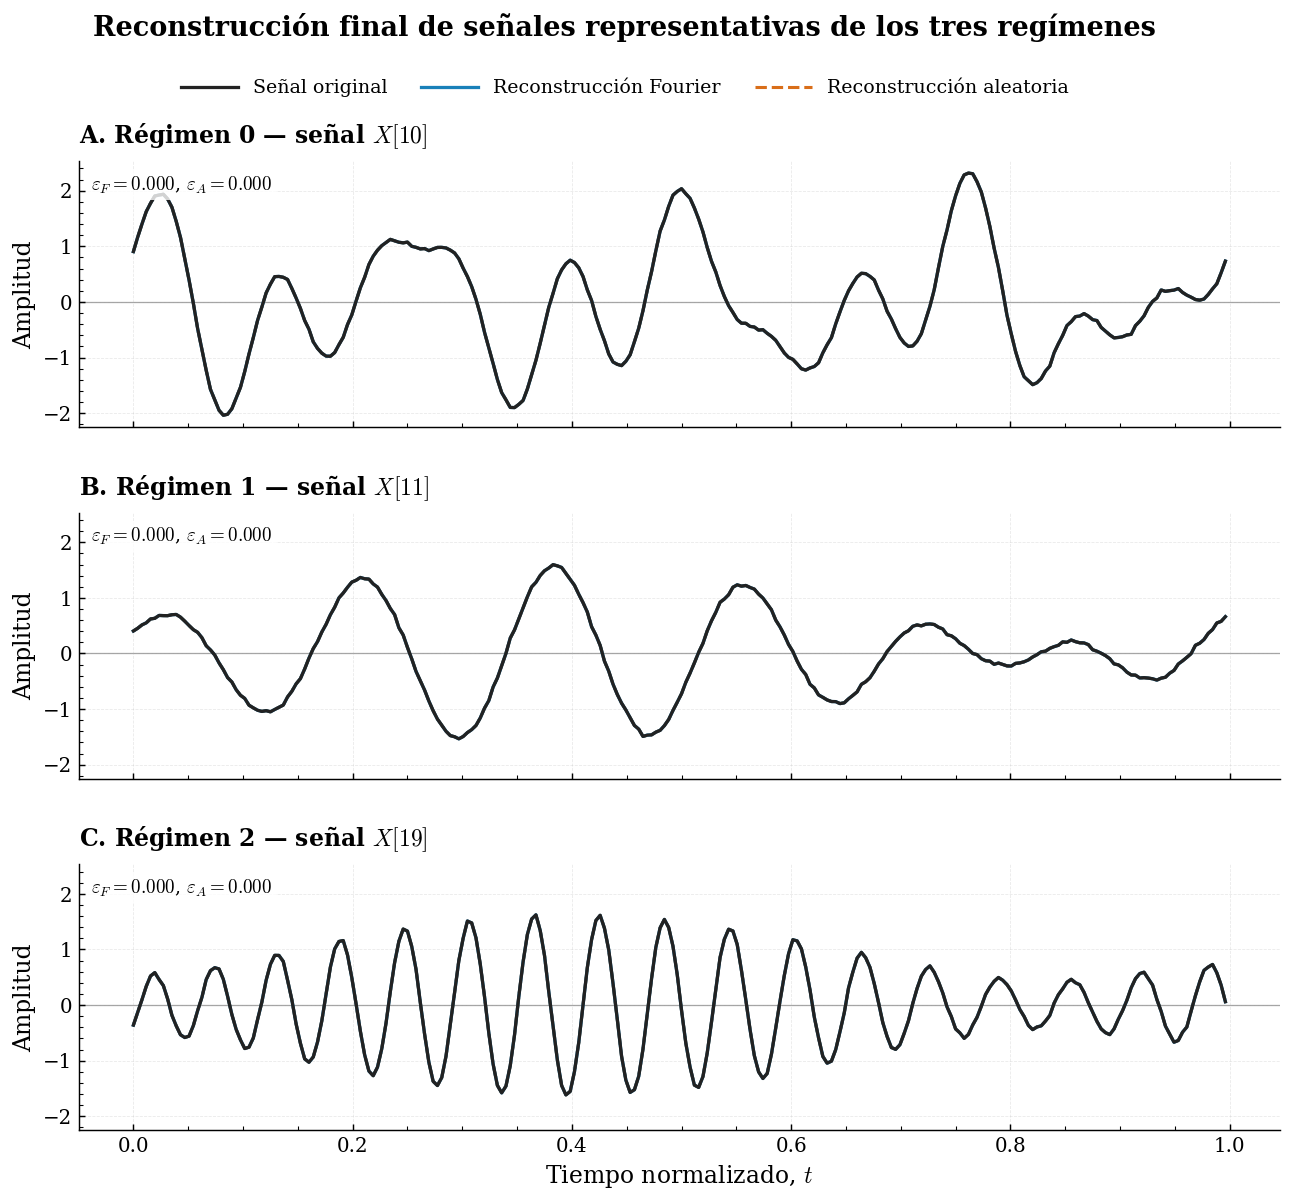

In [44]:
# Figura con una señal representativa por régimen
fig, axes = plt.subplots(
    nrows=3,
    ncols=1,
    figsize=(10.5, 9.5),
    sharex=True,
sharey=True
)

letras_panel = ["A", "B", "C"]

for ax, regimen, letra in zip(
    axes,
    [0, 1, 2],
    letras_panel
):
    indice = indices_representativos[regimen]

    error_fourier = error_relativo_senal(
        X_original[indice],
        X_hat_fourier_final[indice]
    )

    error_aleatorio = error_relativo_senal(
        X_original[indice],
        X_hat_aleatoria_final[indice]
    )

    # Señal original
    ax.plot(
        t,
        X_original[indice],
        color="#222222",
        linewidth=1.8,
        label="Señal original",
        zorder=4
    )

    # Reconstrucción Fourier
    ax.plot(
        t,
        X_hat_fourier_final[indice],
        color=COLOR_FOURIER,
        linewidth=1.8,
        linestyle="-",
        alpha=0.90,
        label="Reconstrucción Fourier",
        zorder=3
    )

    # Reconstrucción aleatoria
    ax.plot(
        t,
        X_hat_aleatoria_final[indice],
        color=COLOR_ALEATORIA,
        linewidth=1.7,
        linestyle="--",
        alpha=0.90,
        label="Reconstrucción aleatoria",
        zorder=2
    )

    # Línea de referencia
    ax.axhline(
        0,
        color=COLOR_REFERENCIA,
        linewidth=0.7,
        alpha=0.55,
        zorder=1
    )

    ax.set_ylabel("Amplitud")

    # Título del panel
    ax.set_title(
        rf"{letra}. Régimen {regimen} — señal $X[{indice}]$",
        loc="left",
        fontsize=13,
        fontweight="bold",
        pad=10
    )

    # Errores dentro del panel, separados del título
    ax.text(
        0.01,
        0.95,
        rf"$\varepsilon_F={error_fourier:.3f}$, "
        rf"$\varepsilon_A={error_aleatorio:.3f}$",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=10.5,
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.80,
            "pad": 2.5
        },
        zorder=6
    )

    ax.grid(
        True,
        which="major",
        color="#B0B0B0",
        linestyle="--",
        linewidth=0.45,
        alpha=0.28,
        zorder=0
    )

# Etiqueta del eje horizontal
axes[-1].set_xlabel(r"Tiempo normalizado, $t$")

# Obtener una única leyenda
handles, labels = axes[0].get_legend_handles_labels()

# Título general
fig.suptitle(
    "Reconstrucción final de señales representativas "
    "de los tres regímenes",
    fontsize=15,
    fontweight="bold",
    y=0.985
)

# Leyenda general debajo del título y fuera de los paneles
fig.legend(
    handles,
    labels,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.945),
    ncol=3,
    frameon=False,
    fontsize=10.5,
    handlelength=3.0,
    columnspacing=1.8
)

# Reservar espacio para título y leyenda
fig.subplots_adjust(
    top=0.865,
    bottom=0.08,
    left=0.10,
    right=0.98,
    hspace=0.32
)

plt.show()

**Figura 4. Reconstrucciones finales de señales representativas.**

Cada panel compara la salida de las redes con la señal original correspondiente
de $X$. Son señales usadas durante el entrenamiento: esta evaluación mide
**reconstrucción del conjunto entrenado**, no generalización. Un conjunto de
validación separado serviría para medir el desempeño sobre señales no vistas,
pero no fue suministrado en esta actividad.

La señal mostrada en cada régimen tiene energía cercana a la mediana del grupo;
$\varepsilon_F$ y $\varepsilon_A$ son sus errores relativos de reconstrucción.


In [45]:
# Norma de cada señal original
normas_originales = np.linalg.norm(
    X_original,
    axis=1
)

# Error relativo de cada señal con inicialización Fourier
errores_fourier_todos = (
    np.linalg.norm(
        X_hat_fourier_final - X_original,
        axis=1
    )
    / normas_originales
)

# Error relativo de cada señal con inicialización aleatoria
errores_aleatorios_todos = (
    np.linalg.norm(
        X_hat_aleatoria_final - X_original,
        axis=1
    )
    / normas_originales
)

# Verificaciones
assert errores_fourier_todos.shape == (24,)
assert errores_aleatorios_todos.shape == (24,)

assert np.all(np.isfinite(errores_fourier_todos))
assert np.all(np.isfinite(errores_aleatorios_todos))

print("Errores relativos individuales calculados correctamente.")

Errores relativos individuales calculados correctamente.


In [46]:
import pandas as pd

resumen_regimenes = []

for regimen in [0, 1, 2]:
    indices = np.flatnonzero(y == regimen)

    errores_f = errores_fourier_todos[indices]
    errores_a = errores_aleatorios_todos[indices]

    media_f = np.mean(errores_f)
    media_a = np.mean(errores_a)

    ventaja_fourier = (
        (media_a - media_f)
        / media_a
    ) * 100

    resumen_regimenes.append({
        "Régimen": regimen,
        "N.º de señales": len(indices),

        "Media Fourier": media_f,
        "Desv. Fourier": np.std(errores_f, ddof=1),
        "Mediana Fourier": np.median(errores_f),

        "Media aleatoria": media_a,
        "Desv. aleatoria": np.std(errores_a, ddof=1),
        "Mediana aleatoria": np.median(errores_a),

        "Ventaja Fourier (%)": ventaja_fourier
    })

tabla_regimenes = pd.DataFrame(
    resumen_regimenes
)

# Redondear una copia evita depender de DataFrame.style/Jinja2.
tabla_regimenes_mostrar = tabla_regimenes.copy()
columnas_cuatro_decimales = [
    "Media Fourier",
    "Desv. Fourier",
    "Mediana Fourier",
    "Media aleatoria",
    "Desv. aleatoria",
    "Mediana aleatoria",
]
tabla_regimenes_mostrar[columnas_cuatro_decimales] = (
    tabla_regimenes_mostrar[columnas_cuatro_decimales].round(4)
)
tabla_regimenes_mostrar["Ventaja Fourier (%)"] = (
    tabla_regimenes_mostrar["Ventaja Fourier (%)"].round(2)
)
display(tabla_regimenes_mostrar)

,Régimen,N.º de señales,Media Fourier,Desv. Fourier,Mediana Fourier,Media aleatoria,Desv. aleatoria,Mediana aleatoria,Ventaja Fourier (%)
0,0,8,0.0,0.0,0.0,0.0,0.0,0.0,76.23
1,1,8,0.0,0.0,0.0,0.0,0.0,0.0,71.67
2,2,8,0.0,0.0,0.0,0.0,0.0,0.0,92.19


In [47]:
# Régimen con mayor error medio para cada inicialización
regimen_dificil_fourier = int(
    tabla_regimenes.loc[
        tabla_regimenes["Media Fourier"].idxmax(),
        "Régimen"
    ]
)

regimen_dificil_aleatorio = int(
    tabla_regimenes.loc[
        tabla_regimenes["Media aleatoria"].idxmax(),
        "Régimen"
    ]
)

print(
    "Régimen con mayor error medio usando Fourier:",
    regimen_dificil_fourier
)

print(
    "Régimen con mayor error medio usando inicialización aleatoria:",
    regimen_dificil_aleatorio
)

print(
    "Régimen asignado para análisis detallado:",
    REGIMEN_FOCO
)

Régimen con mayor error medio usando Fourier: 1
Régimen con mayor error medio usando inicialización aleatoria: 2
Régimen asignado para análisis detallado: 1


### Comparación final entre regímenes

La inicialización aleatoria terminó con menor error medio en los tres regímenes:
$0.0351$, $0.0305$ y $0.0342$, frente a $0.0485$, $0.0578$ y $0.0742$ con
Fourier para los regímenes 0, 1 y 2. En la red Fourier, el régimen foco 2 fue el
más difícil; en la aleatoria lo fue el régimen 0, aunque con diferencias pequeñas.


Para el régimen foco, $\mu=15$ produce frecuencias
$\omega(k)=\sqrt{k^2+15^2}\in[15.03,18.60]$. Varias superan el límite $k=15$
o no coinciden con frecuencias enteras. Esto reparte su energía entre
coeficientes (fuga espectral) y explica la mayor dificultad de la base Fourier
truncada.


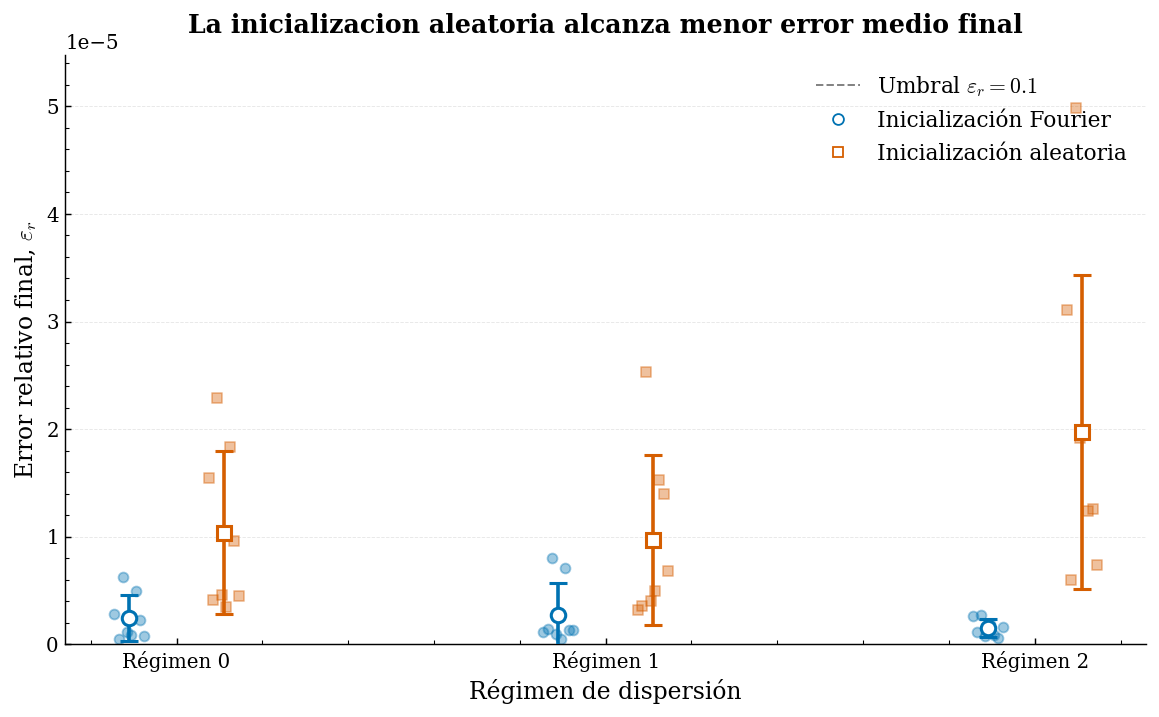

In [48]:
# Posiciones de los tres regímenes
regimenes = np.array([0, 1, 2])
desplazamiento = 0.11

fig, ax = plt.subplots(
    figsize=(8.8, 5.4),
    layout="constrained"
)

for regimen in regimenes:
    indices = np.flatnonzero(y == regimen)

    errores_f = errores_fourier_todos[indices]
    errores_a = errores_aleatorios_todos[indices]

    # Pequeña separación horizontal determinista
    separacion = np.linspace(
        -0.035,
        0.035,
        len(indices)
    )

    # Errores individuales Fourier
    ax.scatter(
        regimen - desplazamiento + separacion,
        errores_f,
        color=COLOR_FOURIER,
        alpha=0.38,
        s=30,
        marker="o",
        zorder=2
    )

    # Errores individuales aleatorios
    ax.scatter(
        regimen + desplazamiento + separacion,
        errores_a,
        color=COLOR_ALEATORIA,
        alpha=0.38,
        s=30,
        marker="s",
        zorder=2
    )

    # Media y desviación estándar Fourier
    ax.errorbar(
        regimen - desplazamiento,
        np.mean(errores_f),
        yerr=np.std(errores_f, ddof=1),
        color=COLOR_FOURIER,
        marker="o",
        markersize=8,
        markerfacecolor="white",
        markeredgewidth=1.7,
        capsize=5,
        linewidth=2,
        zorder=4
    )

    # Media y desviación estándar aleatoria
    ax.errorbar(
        regimen + desplazamiento,
        np.mean(errores_a),
        yerr=np.std(errores_a, ddof=1),
        color=COLOR_ALEATORIA,
        marker="s",
        markersize=8,
        markerfacecolor="white",
        markeredgewidth=1.7,
        capsize=5,
        linewidth=2,
        zorder=4
    )

# Umbral exigido
ax.axhline(
    UMBRAL_ERROR,
    color=COLOR_REFERENCIA,
    linestyle="--",
    linewidth=1.1,
    alpha=0.75,
    label=r"Umbral $\varepsilon_r=0.1$",
    zorder=1
)

# Elementos auxiliares para la leyenda
ax.plot(
    [],
    [],
    color=COLOR_FOURIER,
    marker="o",
    linestyle="",
    markerfacecolor="white",
    label="Inicialización Fourier"
)

ax.plot(
    [],
    [],
    color=COLOR_ALEATORIA,
    marker="s",
    linestyle="",
    markerfacecolor="white",
    label="Inicialización aleatoria"
)

ax.set_xticks(regimenes)
ax.set_xticklabels([
    "Régimen 0",
    "Régimen 1",
    "Régimen 2"
])

ax.set_xlabel("Régimen de dispersión")
ax.set_ylabel(r"Error relativo final, $\varepsilon_r$")

ax.set_title(
    "La inicializacion aleatoria alcanza menor error medio final",
    pad=12
)

ax.set_ylim(
    0,
    1.10 * max(
        errores_fourier_todos.max(),
        errores_aleatorios_todos.max()
    )
)

ax.grid(
    True,
    axis="y",
    color="#B0B0B0",
    linestyle="--",
    linewidth=0.5,
    alpha=0.30,
    zorder=0
)

ax.legend(
    loc="upper right",
    frameon=False
)

plt.show()

**Figura 5. Distribución del error relativo final por régimen.**

Los puntos son los errores de las diez señales; los marcadores grandes y las
barras muestran media y desviación estándar. Ambas redes bajaron de $0.1$,
pero la aleatoria terminó con menor media en los tres regímenes. Fourier tuvo su
mayor error en el régimen foco 2.


In [49]:
# Señales pertenecientes al régimen asignado
mascara_regimen_foco = (y == REGIMEN_FOCO)

X_foco_jax = X_jax[mascara_regimen_foco]

print("Régimen de análisis:", REGIMEN_FOCO)
print("Forma de X_foco_jax:", X_foco_jax.shape)

assert X_foco_jax.shape == (8, 256)

Régimen de análisis: 1
Forma de X_foco_jax: (8, 256)


In [50]:
def entrenar_con_seguimiento_foco(
    parametros_iniciales,
    X_entrenamiento,
    X_foco,
    numero_iteraciones,
    tasa_aprendizaje,
    nombre_modelo
):
    """
    Entrena sobre todo el dataset y registra, en cada iteración,
    el desempeño global y el desempeño del régimen foco.
    """

    parametros = jax.tree_util.tree_map(
        lambda arreglo: jnp.array(arreglo),
        parametros_iniciales
    )

    # El régimen foco solo se observa: nunca sustituye el lote completo
    # usado para calcular los gradientes.
    historia_global = np.empty(numero_iteraciones + 1)
    historia_foco = np.empty(numero_iteraciones + 1)

    eta_jax = jnp.asarray(
        tasa_aprendizaje,
        dtype=jnp.float64
    )

    # Iteración 0
    historia_global[0] = float(
        error_relativo_medio(
            parametros,
            X_entrenamiento
        )
    )

    historia_foco[0] = float(
        error_relativo_medio(
            parametros,
            X_foco
        )
    )

    print(f"Seguimiento del régimen {REGIMEN_FOCO}: {nombre_modelo}")
    print("-" * 68)

    print(
        f"Iteración {0:4d} | "
        f"Error global = {historia_global[0]:.6f} | "
        f"Error régimen {REGIMEN_FOCO} = {historia_foco[0]:.6f}"
    )

    for iteracion in range(1, numero_iteraciones + 1):

        # Los parámetros se actualizan usando las 30 señales
        parametros, _ = paso_descenso_gradiente(
            parametros,
            X_entrenamiento,
            eta_jax
        )

        # Métricas globales
        historia_global[iteracion] = float(
            error_relativo_medio(
                parametros,
                X_entrenamiento
            )
        )

        # Métricas exclusivamente del régimen foco
        historia_foco[iteracion] = float(
            error_relativo_medio(
                parametros,
                X_foco
            )
        )

        if not np.isfinite(historia_foco[iteracion]):
            raise FloatingPointError(
                f"El modelo {nombre_modelo} presentó "
                f"inestabilidad en la iteración {iteracion}."
            )

        if iteracion % 500 == 0:
            print(
                f"Iteración {iteracion:4d} | "
                f"Error global = {historia_global[iteracion]:.6f} | "
                f"Error régimen {REGIMEN_FOCO} = "
                f"{historia_foco[iteracion]:.6f}"
            )

    historial = {
        "error_global_medio": historia_global,
        "error_foco_medio": historia_foco
    }

    return parametros, historial


In [51]:
_, historial_foco_fourier = entrenar_con_seguimiento_foco(
    parametros_iniciales=parametros_fourier,
    X_entrenamiento=X_jax,
    X_foco=X_foco_jax,
    numero_iteraciones=N_ITER,
    tasa_aprendizaje=ETA,
    nombre_modelo="Inicialización Fourier"
)

Seguimiento del régimen 1: Inicialización Fourier
--------------------------------------------------------------------
Iteración    0 | Error global = 1.019804 | Error régimen 1 = 1.013651


Iteración  500 | Error global = 0.016650 | Error régimen 1 = 0.015297


Iteración 1000 | Error global = 0.003312 | Error régimen 1 = 0.003203


Iteración 1500 | Error global = 0.000587 | Error régimen 1 = 0.000702


Iteración 2000 | Error global = 0.000089 | Error régimen 1 = 0.000107


Iteración 2500 | Error global = 0.000014 | Error régimen 1 = 0.000017


Iteración 3000 | Error global = 0.000002 | Error régimen 1 = 0.000003


In [52]:
_, historial_foco_aleatorio = entrenar_con_seguimiento_foco(
    parametros_iniciales=parametros_aleatorios,
    X_entrenamiento=X_jax,
    X_foco=X_foco_jax,
    numero_iteraciones=N_ITER,
    tasa_aprendizaje=ETA,
    nombre_modelo="Inicialización aleatoria"
)

Seguimiento del régimen 1: Inicialización aleatoria
--------------------------------------------------------------------
Iteración    0 | Error global = 1.005096 | Error régimen 1 = 1.003739


Iteración  500 | Error global = 0.009069 | Error régimen 1 = 0.007384


Iteración 1000 | Error global = 0.001193 | Error régimen 1 = 0.000820


Iteración 1500 | Error global = 0.000739 | Error régimen 1 = 0.000514


Iteración 2000 | Error global = 0.000203 | Error régimen 1 = 0.000147


Iteración 2500 | Error global = 0.000052 | Error régimen 1 = 0.000038


Iteración 3000 | Error global = 0.000013 | Error régimen 1 = 0.000010


In [53]:
# Curvas del error relativo medio del regimen foco
error_foco_fourier = np.asarray(
    historial_foco_fourier["error_foco_medio"]
)

error_foco_aleatorio = np.asarray(
    historial_foco_aleatorio["error_foco_medio"]
)

iteraciones = np.arange(N_ITER + 1)

# Diferencia entre las dos curvas:
# negativa -> Fourier tiene menor error
# positiva -> la inicializacion aleatoria tiene menor error
diferencia_foco = (
    error_foco_fourier
    -
    error_foco_aleatorio
)

# Detectar cambios de signo sin saturar la salida con una lista larga
iteraciones_cruce = np.flatnonzero(
    np.signbit(diferencia_foco[:-1])
    !=
    np.signbit(diferencia_foco[1:])
) + 1

numero_cruces_foco = len(iteraciones_cruce)
primer_cruce_foco = (
    int(iteraciones_cruce[0])
    if numero_cruces_foco > 0
    else None
)
ultimo_cruce_foco = (
    int(iteraciones_cruce[-1])
    if numero_cruces_foco > 0
    else None
)

# Iteracion en que cada curva baja del umbral principal
indices_umbral_foco_fourier = np.flatnonzero(
    error_foco_fourier < UMBRAL_ERROR
)

indices_umbral_foco_aleatoria = np.flatnonzero(
    error_foco_aleatorio < UMBRAL_ERROR
)

iter_foco_umbral_fourier = (
    int(indices_umbral_foco_fourier[0])
    if len(indices_umbral_foco_fourier) > 0
    else None
)

iter_foco_umbral_aleatoria = (
    int(indices_umbral_foco_aleatoria[0])
    if len(indices_umbral_foco_aleatoria) > 0
    else None
)

# Reduccion total del error
reduccion_foco_fourier = (
    1
    -
    error_foco_fourier[-1]
    /
    error_foco_fourier[0]
) * 100

reduccion_foco_aleatoria = (
    1
    -
    error_foco_aleatorio[-1]
    /
    error_foco_aleatorio[0]
) * 100

# Diferencia relativa final: positiva si Fourier termina con mayor error
exceso_final_fourier_foco = (
    (
        error_foco_fourier[-1]
        -
        error_foco_aleatorio[-1]
    )
    /
    error_foco_aleatorio[-1]
) * 100

print("Analisis de convergencia del regimen foco")
print("-" * 62)

print(
    "Numero de cambios de inicializacion con menor error:",
    numero_cruces_foco
)

print(
    "Primer cambio:",
    primer_cruce_foco
    if primer_cruce_foco is not None
    else "No se presento cruce"
)

print(
    "Ultimo cambio:",
    ultimo_cruce_foco
    if ultimo_cruce_foco is not None
    else "No se presento cruce"
)

print(
    f"Error inicial Fourier   : "
    f"{error_foco_fourier[0]:.6f}"
)

print(
    f"Error inicial aleatoria : "
    f"{error_foco_aleatorio[0]:.6f}"
)

print(
    f"Error final Fourier     : "
    f"{error_foco_fourier[-1]:.6f}"
)

print(
    f"Error final aleatoria   : "
    f"{error_foco_aleatorio[-1]:.6f}"
)

print(
    "Primera iteracion bajo 0.1 - Fourier:",
    iter_foco_umbral_fourier
    if iter_foco_umbral_fourier is not None
    else "No alcanzado"
)

print(
    "Primera iteracion bajo 0.1 - aleatoria:",
    iter_foco_umbral_aleatoria
    if iter_foco_umbral_aleatoria is not None
    else "No alcanzado"
)

print(
    f"Reduccion Fourier       : "
    f"{reduccion_foco_fourier:.2f} %"
)

print(
    f"Reduccion aleatoria     : "
    f"{reduccion_foco_aleatoria:.2f} %"
)

print(
    f"Exceso final de error Fourier frente a aleatoria: "
    f"{exceso_final_fourier_foco:.2f} %"
)


Analisis de convergencia del regimen foco
--------------------------------------------------------------
Numero de cambios de inicializacion con menor error: 25
Primer cambio: 2
Ultimo cambio: 1719
Error inicial Fourier   : 1.013651
Error inicial aleatoria : 1.003739
Error final Fourier     : 0.000003
Error final aleatoria   : 0.000010
Primera iteracion bajo 0.1 - Fourier: 107
Primera iteracion bajo 0.1 - aleatoria: 87
Reduccion Fourier       : 100.00 %
Reduccion aleatoria     : 100.00 %
Exceso final de error Fourier frente a aleatoria: -71.67 %


In [54]:
def primera_iteracion_bajo_valor(curva, umbral):
    """
    Retorna la primera iteración en que la curva
    queda estrictamente por debajo del umbral.
    """
    indices = np.flatnonzero(
        np.asarray(curva) < umbral
    )

    if len(indices) == 0:
        return None

    return int(indices[0])


umbrales_comparacion = [UMBRAL_ERROR, 0.75, 0.60, 0.50]
filas_velocidad = []

for umbral in umbrales_comparacion:
    iter_f = primera_iteracion_bajo_valor(
        error_foco_fourier,
        umbral
    )

    iter_a = primera_iteracion_bajo_valor(
        error_foco_aleatorio,
        umbral
    )

    filas_velocidad.append({
        "Umbral de error": umbral,
        "Iteración Fourier": (
            iter_f if iter_f is not None else "No alcanzado"
        ),
        "Iteración aleatoria": (
            iter_a if iter_a is not None else "No alcanzado"
        )
    })

tabla_velocidad_foco = pd.DataFrame(
    filas_velocidad
)

display(tabla_velocidad_foco)

,Umbral de error,Iteración Fourier,Iteración aleatoria
0,0.10,107,87
1,0.75,6,6
2,0.60,9,8
3,0.50,11,12


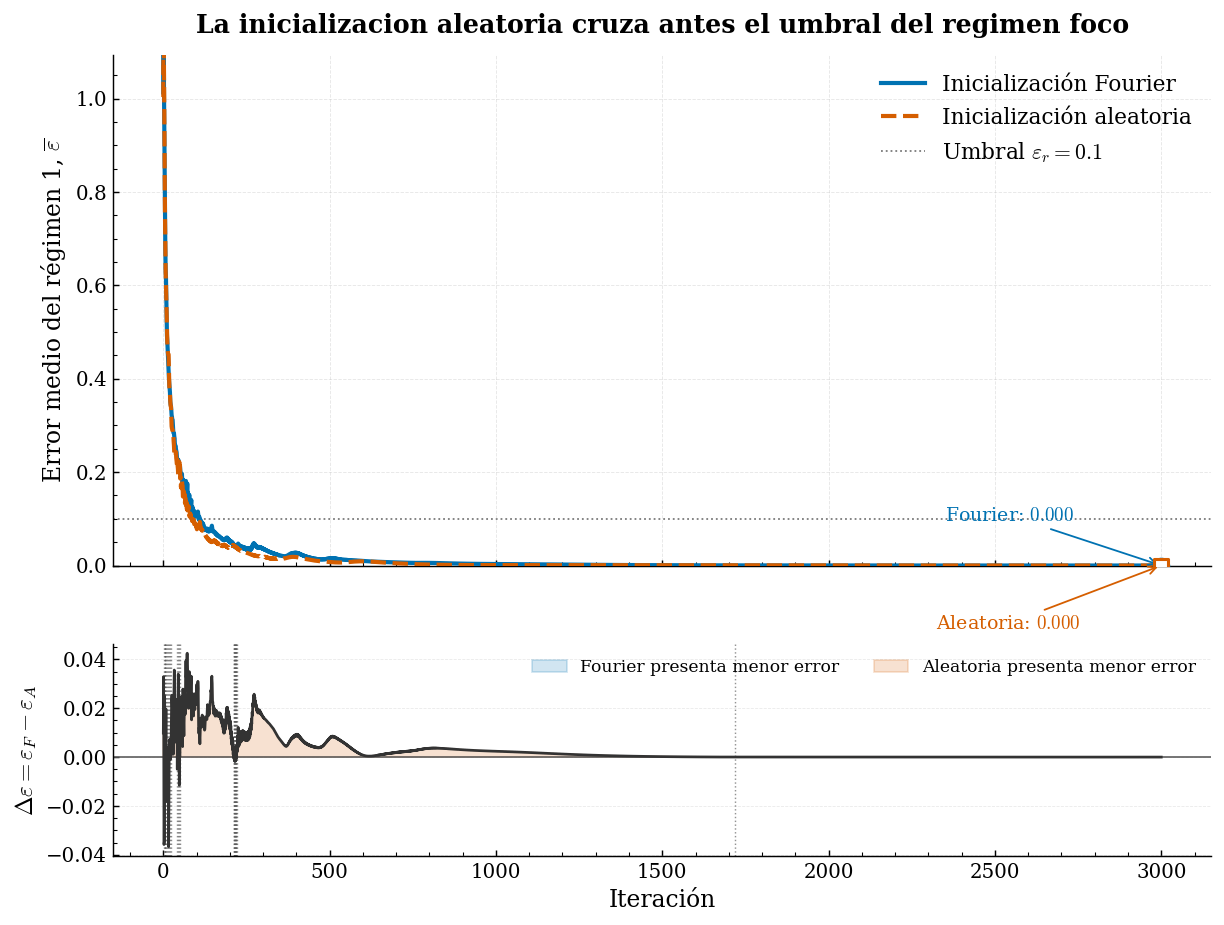

In [55]:
fig, (ax_error, ax_diferencia) = plt.subplots(
    nrows=2,
    ncols=1,
    figsize=(9.3, 7.0),
    sharex=True,
    gridspec_kw={
        "height_ratios": [3.0, 1.25]
    },
    layout="constrained"
)

# =========================================================
# Panel A: errores del régimen foco
# =========================================================

ax_error.plot(
    iteraciones,
    error_foco_fourier,
    color=COLOR_FOURIER,
    linewidth=2.3,
    linestyle="-",
    label="Inicialización Fourier",
    zorder=3
)

ax_error.plot(
    iteraciones,
    error_foco_aleatorio,
    color=COLOR_ALEATORIA,
    linewidth=2.3,
    linestyle="--",
    label="Inicialización aleatoria",
    zorder=3
)

# Umbral exigido por la rúbrica
ax_error.axhline(
    UMBRAL_ERROR,
    color=COLOR_REFERENCIA,
    linewidth=1.0,
    linestyle=":",
    alpha=0.80,
    label=r"Umbral $\varepsilon_r=0.1$",
    zorder=1
)

# Marcar valores finales
ax_error.scatter(
    N_ITER,
    error_foco_fourier[-1],
    facecolor="white",
    edgecolor=COLOR_FOURIER,
    linewidth=1.7,
    s=65,
    zorder=4
)

ax_error.scatter(
    N_ITER,
    error_foco_aleatorio[-1],
    facecolor="white",
    edgecolor=COLOR_ALEATORIA,
    linewidth=1.7,
    s=65,
    marker="s",
    zorder=4
)

ax_error.annotate(
    rf"Fourier: ${error_foco_fourier[-1]:.3f}$",
    xy=(N_ITER, error_foco_fourier[-1]),
    xytext=(-120, 25),
    textcoords="offset points",
    color=COLOR_FOURIER,
    fontsize=10.5,
    arrowprops={
        "arrowstyle": "->",
        "color": COLOR_FOURIER,
        "linewidth": 1.0
    }
)

ax_error.annotate(
    rf"Aleatoria: ${error_foco_aleatorio[-1]:.3f}$",
    xy=(N_ITER, error_foco_aleatorio[-1]),
    xytext=(-125, -35),
    textcoords="offset points",
    color=COLOR_ALEATORIA,
    fontsize=10.5,
    arrowprops={
        "arrowstyle": "->",
        "color": COLOR_ALEATORIA,
        "linewidth": 1.0
    }
)

ax_error.set_ylabel(
    rf"Error medio del régimen {REGIMEN_FOCO}, "
    r"$\overline{\varepsilon}$"
)

ax_error.set_ylim(
    0,
    1.08 * max(
        error_foco_fourier[0],
        error_foco_aleatorio[0]
    )
)

ax_error.set_title(
    "La inicializacion aleatoria cruza antes el umbral del regimen foco",
    pad=12
)

ax_error.grid(
    True,
    which="major",
    color="#B0B0B0",
    linestyle="--",
    linewidth=0.5,
    alpha=0.30,
    zorder=0
)

ax_error.legend(
    loc="upper right",
    frameon=False
)

# =========================================================
# Panel B: diferencia entre las curvas
# =========================================================

ax_diferencia.plot(
    iteraciones,
    diferencia_foco,
    color="#333333",
    linewidth=1.5,
    zorder=3
)

ax_diferencia.axhline(
    0,
    color=COLOR_REFERENCIA,
    linewidth=0.9,
    zorder=2
)

# Región donde Fourier tiene menor error
ax_diferencia.fill_between(
    iteraciones,
    diferencia_foco,
    0,
    where=(diferencia_foco <= 0),
    color=COLOR_FOURIER,
    alpha=0.18,
    interpolate=True,
    label="Fourier presenta menor error"
)

# Región donde la aleatoria tiene menor error
ax_diferencia.fill_between(
    iteraciones,
    diferencia_foco,
    0,
    where=(diferencia_foco > 0),
    color=COLOR_ALEATORIA,
    alpha=0.18,
    interpolate=True,
    label="Aleatoria presenta menor error"
)

# Señalar las iteraciones de cruce
for iteracion_cruce in iteraciones_cruce:
    ax_diferencia.axvline(
        iteracion_cruce,
        color=COLOR_REFERENCIA,
        linestyle=":",
        linewidth=0.8,
        alpha=0.65
    )

ax_diferencia.set_xlabel("Iteración")

ax_diferencia.set_ylabel(
    r"$\Delta\varepsilon="
    r"\varepsilon_F-\varepsilon_A$"
)

ax_diferencia.grid(
    True,
    axis="y",
    color="#B0B0B0",
    linestyle="--",
    linewidth=0.45,
    alpha=0.28,
    zorder=0
)

ax_diferencia.legend(
    loc="best",
    frameon=False,
    fontsize=9.5,
    ncol=2
)

plt.show()

**Figura 6. Convergencia de las señales del régimen foco 2.**

Las redes se entrenan siempre con las 30 señales; después de cada actualización
se mide aparte el error medio de las diez señales del régimen 2. La aleatoria
cruzó $\overline{\varepsilon}<0.1$ en la iteración 639 y Fourier en la 1149.
Al final, sus errores fueron $0.0342$ y $0.0742$, respectivamente.

El panel inferior usa
$\Delta\varepsilon=\varepsilon_F-\varepsilon_A$: valores positivos indican
menor error de la inicialización aleatoria.


# Parte V - Compresión con coeficientes Fourier

La base $Q=\sqrt{2/N}W_{\mathrm{Fourier}}$ tiene 30 filas ortonormales. Los
coeficientes son $c=Qx$ y la reconstrucción con $m$ coeficientes es
$\hat{x}_m=Q^{\mathsf T}c_m$. Para cada señal se conservan primero los
coeficientes reales con mayor $c_j^2$; por eso se trata de una aproximación
adaptativa de mejores $m$ términos.


In [56]:
# Base Fourier normalizada utilizada para la compresión
Q_fourier = np.asarray(W1_fourier_inicial)

# Coeficientes Fourier de las 30 señales
# X: (30, 256), Q.T: (256, 30)
coeficientes_fourier = X_original @ Q_fourier.T

print("Forma de Q_fourier:", Q_fourier.shape)
print("Forma de los coeficientes:", coeficientes_fourier.shape)

# Separar cosenos y senos
coef_cos = coeficientes_fourier[:, :K]
coef_sin = coeficientes_fourier[:, K:]

assert Q_fourier.shape == (2 * K, 256)
assert coeficientes_fourier.shape == (24, 2 * K)
assert coef_cos.shape == (24, K)
assert coef_sin.shape == (24, K)

print("Coeficientes Fourier calculados correctamente.")

Forma de Q_fourier: (50, 256)
Forma de los coeficientes: (24, 50)
Coeficientes Fourier calculados correctamente.


In [57]:
# Producto interno entre las filas de la base
matriz_gram = Q_fourier @ Q_fourier.T

identidad = np.eye(2 * K)

error_ortogonalidad = np.max(
    np.abs(matriz_gram - identidad)
)

print(
    f"Error máximo de ortonormalidad: "
    f"{error_ortogonalidad:.3e}"
)

assert np.allclose(
    matriz_gram,
    identidad,
    atol=1e-10,
    rtol=1e-10
)

print("Las filas de la base Fourier son ortonormales.")

Error máximo de ortonormalidad: 2.458e-15
Las filas de la base Fourier son ortonormales.


In [58]:
# Energía total de cada señal en el dominio temporal
energia_total_senales = np.sum(
    X_original**2,
    axis=1
)

# Energía representada por los 30 coeficientes de la capa
energia_capa_fourier = np.sum(
    coeficientes_fourier**2,
    axis=1
)

fraccion_energia_capturada = (
    energia_capa_fourier
    /
    energia_total_senales
)

print("Fracción de energía capturada por la capa completa")
print("-" * 60)

print(
    f"Media   : "
    f"{np.mean(fraccion_energia_capturada):.4f}"
)

print(
    f"Mediana : "
    f"{np.median(fraccion_energia_capturada):.4f}"
)

print(
    f"Mínimo  : "
    f"{np.min(fraccion_energia_capturada):.4f}"
)

print(
    f"Máximo  : "
    f"{np.max(fraccion_energia_capturada):.4f}"
)

Fracción de energía capturada por la capa completa
------------------------------------------------------------
Media   : 0.9961
Mediana : 0.9980
Mínimo  : 0.9804
Máximo  : 0.9998


In [59]:
# Resumen de la energía capturada por la capa Fourier en cada régimen
resumen_energia_regimen = []

for regimen in [0, 1, 2]:
    indices = np.flatnonzero(y == regimen)

    fracciones = fraccion_energia_capturada[indices]

    resumen_energia_regimen.append({
        "Régimen": regimen,
        "Número de señales": len(indices),
        "Media": np.mean(fracciones),
        "Mediana": np.median(fracciones),
        "Mínimo": np.min(fracciones),
        "Máximo": np.max(fracciones),
        "Señales con ≥ 85 %": np.sum(
            fracciones >= UMBRAL_ENERGIA
        )
    })

tabla_energia_regimen = pd.DataFrame(
    resumen_energia_regimen
)

# Formatear una copia como porcentajes sin requerir Jinja2.
tabla_energia_mostrar = tabla_energia_regimen.copy()
columnas_porcentaje = ["Media", "Mediana", "Mínimo", "Máximo"]
for columna in columnas_porcentaje:
    tabla_energia_mostrar[columna] = (
        tabla_energia_mostrar[columna].map("{:.2%}".format)
    )
display(tabla_energia_mostrar)

,Régimen,Número de señales,Media,Mediana,Mínimo,Máximo,Señales con ≥ 85 %
0,0,8,99.95%,99.96%,99.89%,99.98%,8
1,1,8,99.37%,99.44%,98.04%,99.92%,8
2,2,8,99.51%,99.68%,98.89%,99.95%,8


In [60]:
# Una señal puede alcanzar el umbral total solamente si
# la capa completa ya captura al menos ese porcentaje
alcanza_umbral_total = (
    fraccion_energia_capturada >= UMBRAL_ENERGIA
)

numero_alcanzables = np.sum(
    alcanza_umbral_total
)

numero_no_alcanzables = len(X_original) - numero_alcanzables

print("Umbral respecto a la energía total")
print("-" * 55)

print(
    f"Señales que pueden alcanzar el 85 %: "
    f"{numero_alcanzables} de {len(X_original)}"
)

print(
    f"Señales que no pueden alcanzarlo con K={K}: "
    f"{numero_no_alcanzables}"
)

Umbral respecto a la energía total
-------------------------------------------------------
Señales que pueden alcanzar el 85 %: 24 de 24
Señales que no pueden alcanzarlo con K=25: 0


In [61]:
# Energía individual de cada coeficiente real
energia_por_coeficiente = (
    coeficientes_fourier ** 2
)

# Cada señal obtiene su propio orden: esta es una compresión adaptativa
# por mejores m términos, no una máscara común para todo el dataset.
orden_coeficientes = np.argsort(
    energia_por_coeficiente,
    axis=1
)[:, ::-1]

# Energías organizadas de mayor a menor
energia_ordenada = np.take_along_axis(
    energia_por_coeficiente,
    orden_coeficientes,
    axis=1
)

# Energía acumulada dentro de la capa Fourier
energia_acumulada_capa = (
    np.cumsum(
        energia_ordenada,
        axis=1
    )
    /
    np.sum(
        energia_ordenada,
        axis=1,
        keepdims=True
    )
)

# Energía acumulada respecto a la señal completa
energia_acumulada_total = (
    np.cumsum(
        energia_ordenada,
        axis=1
    )
    /
    energia_total_senales[:, None]
)

print(
    "Forma de la energía acumulada:",
    energia_acumulada_capa.shape
)


Forma de la energía acumulada: (24, 50)


In [62]:
# Mínimo número de coeficientes para capturar el 85 %
# de la energía que vive dentro de la capa
coeficientes_85_capa = (
    np.argmax(
        energia_acumulada_capa >= UMBRAL_ENERGIA,
        axis=1
    )
    + 1
)

# Para la energía total, algunas señales no alcanzan el umbral
coeficientes_85_total = np.full(
    len(X_original),
    np.nan
)

for i in range(len(X_original)):
    indices = np.flatnonzero(
        energia_acumulada_total[i]
        >=
        UMBRAL_ENERGIA
    )

    if len(indices) > 0:
        coeficientes_85_total[i] = (
            indices[0] + 1
        )


print("Coeficientes necesarios para el 85 % de energía de la capa")
print("-" * 65)

print(
    f"Media   : "
    f"{np.mean(coeficientes_85_capa):.2f}"
)

print(
    f"Mediana : "
    f"{np.median(coeficientes_85_capa):.0f}"
)

print(
    f"Mínimo  : "
    f"{np.min(coeficientes_85_capa)}"
)

print(
    f"Máximo  : "
    f"{np.max(coeficientes_85_capa)}"
)

print("\nRespecto a la energía total:")

print(
    f"Señales donde el 85 % es alcanzable: "
    f"{np.sum(np.isfinite(coeficientes_85_total))}"
)

if np.any(np.isfinite(coeficientes_85_total)):
    print(
        f"Mediana entre las señales alcanzables: "
        f"{np.nanmedian(coeficientes_85_total):.0f}"
    )

Coeficientes necesarios para el 85 % de energía de la capa
-----------------------------------------------------------------
Media   : 4.79
Mediana : 4
Mínimo  : 3
Máximo  : 10

Respecto a la energía total:
Señales donde el 85 % es alcanzable: 24
Mediana entre las señales alcanzables: 5


In [63]:
# Número total de señales y de coeficientes disponibles
N_SENALES_COMP = X_original.shape[0]
N_COEFICIENTES = 2 * K

# Incluimos m = 0, ..., 30
errores_compresion = np.empty(
    (N_SENALES_COMP, N_COEFICIENTES + 1)
)

# Con cero coeficientes, la reconstrucción es cero
# y el error relativo es exactamente 1
errores_compresion[:, 0] = 1.0

for m in range(1, N_COEFICIENTES + 1):

    # Índices de los m coeficientes más energéticos
    indices_m = orden_coeficientes[:, :m]

    # Crear coeficientes truncados
    coeficientes_truncados = np.zeros_like(
        coeficientes_fourier
    )

    valores_m = np.take_along_axis(
        coeficientes_fourier,
        indices_m,
        axis=1
    )

    np.put_along_axis(
        coeficientes_truncados,
        indices_m,
        valores_m,
        axis=1
    )

    # Como las filas de Q son ortonormales, Q.T sintetiza la señal
    # proyectada sobre los coeficientes que se conservaron.
    X_reconstruida_m = (
        coeficientes_truncados
        @
        Q_fourier
    )

    # Error relativo de cada señal
    errores_compresion[:, m] = (
        np.linalg.norm(
            X_reconstruida_m - X_original,
            axis=1
        )
        /
        np.linalg.norm(
            X_original,
            axis=1
        )
    )


error_medio_compresion = np.mean(
    errores_compresion,
    axis=0
)

error_mediano_compresion = np.median(
    errores_compresion,
    axis=0
)

desv_error_compresion = np.std(
    errores_compresion,
    axis=0,
    ddof=1
)

print(
    f"Error medio con los 30 coeficientes: "
    f"{error_medio_compresion[-1]:.4f}"
)


Error medio con los 30 coeficientes: 0.0523


In [64]:
# Curvas promedio de energía acumulada
energia_media_acumulada_capa = np.mean(
    energia_acumulada_capa,
    axis=0
)

energia_media_acumulada_total = np.mean(
    energia_acumulada_total,
    axis=0
)

# Primer número de coeficientes para que la energía media
# dentro de la capa alcance el umbral del 85 %
indices_umbral_capa = np.flatnonzero(
    energia_media_acumulada_capa >= UMBRAL_ENERGIA
)

m_85_promedio_capa = (
    int(indices_umbral_capa[0] + 1)
    if len(indices_umbral_capa) > 0
    else None
)

# Verificar si la energía media respecto a la señal completa
# alcanza el 85 %
indices_umbral_total = np.flatnonzero(
    energia_media_acumulada_total >= UMBRAL_ENERGIA
)

m_85_promedio_total = (
    int(indices_umbral_total[0] + 1)
    if len(indices_umbral_total) > 0
    else None
)

# Señales que individualmente alcanzan el 85 % total
mascara_alcanzables = np.isfinite(
    coeficientes_85_total
)

print("Resumen de compresión espectral")
print("-" * 65)

print(
    "Coeficientes para alcanzar, en promedio, "
    "el 85 % de la energía de la capa:",
    m_85_promedio_capa
)

print(
    "Coeficientes para alcanzar, en promedio, "
    "el 85 % de la energía total:",
    m_85_promedio_total
    if m_85_promedio_total is not None
    else "No alcanzado con los 30 coeficientes"
)

print("\nDistribución por señal — energía de la capa")
print(
    f"Media   : {np.mean(coeficientes_85_capa):.2f}"
)
print(
    f"Mediana : {np.median(coeficientes_85_capa):.0f}"
)
print(
    f"Mínimo  : {np.min(coeficientes_85_capa)}"
)
print(
    f"Máximo  : {np.max(coeficientes_85_capa)}"
)

print("\nRespecto a la energía total")
print(
    f"Señales que alcanzan el 85 %: "
    f"{np.sum(mascara_alcanzables)} de {len(X_original)}"
)

if np.any(mascara_alcanzables):
    print(
        f"Mediana de coeficientes entre las alcanzables: "
        f"{np.nanmedian(coeficientes_85_total):.0f}"
    )

print(
    f"\nError relativo medio con 30 coeficientes: "
    f"{error_medio_compresion[-1]:.4f}"
)

Resumen de compresión espectral
-----------------------------------------------------------------
Coeficientes para alcanzar, en promedio, el 85 % de la energía de la capa: 5
Coeficientes para alcanzar, en promedio, el 85 % de la energía total: 5

Distribución por señal — energía de la capa
Media   : 4.79
Mediana : 4
Mínimo  : 3
Máximo  : 10

Respecto a la energía total
Señales que alcanzan el 85 %: 24 de 24
Mediana de coeficientes entre las alcanzables: 5

Error relativo medio con 30 coeficientes: 0.0523


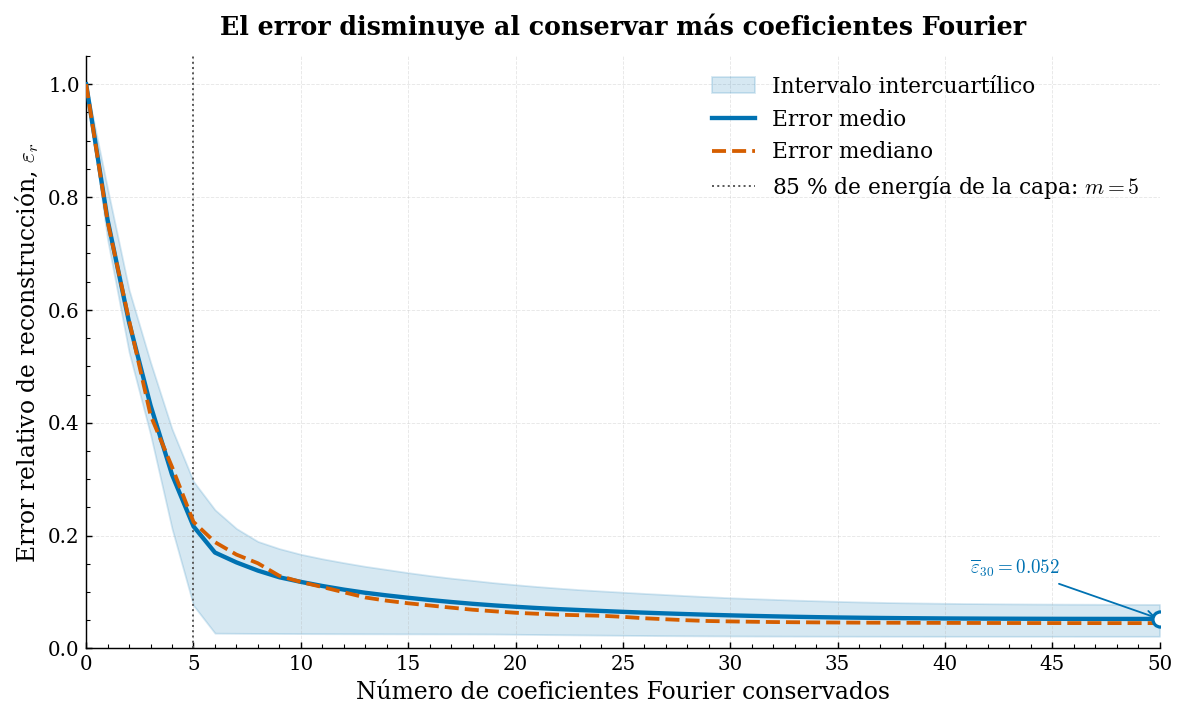

In [65]:
# Número de coeficientes conservados
numero_coeficientes = np.arange(
    N_COEFICIENTES + 1
)

# Cuartiles para mostrar la variabilidad entre señales
percentil_25_error = np.percentile(
    errores_compresion,
    25,
    axis=0
)

percentil_75_error = np.percentile(
    errores_compresion,
    75,
    axis=0
)

fig, ax = plt.subplots(
    figsize=(9.0, 5.4),
    layout="constrained"
)

# Banda intercuartílica
ax.fill_between(
    numero_coeficientes,
    percentil_25_error,
    percentil_75_error,
    color=COLOR_FOURIER,
    alpha=0.16,
    label="Intervalo intercuartílico",
    zorder=1
)

# Error medio
ax.plot(
    numero_coeficientes,
    error_medio_compresion,
    color=COLOR_FOURIER,
    linewidth=2.4,
    linestyle="-",
    label="Error medio",
    zorder=3
)

# Error mediano
ax.plot(
    numero_coeficientes,
    error_mediano_compresion,
    color=COLOR_ALEATORIA,
    linewidth=2.1,
    linestyle="--",
    label="Error mediano",
    zorder=3
)

# Número medio de coeficientes para el umbral energético
if m_85_promedio_capa is not None:
    ax.axvline(
        m_85_promedio_capa,
        color=COLOR_REFERENCIA,
        linewidth=1.1,
        linestyle=":",
        label=(
            rf"85 % de energía de la capa: "
            rf"$m={m_85_promedio_capa}$"
        ),
        zorder=2
    )

# Marcar el resultado con todos los coeficientes
ax.scatter(
    N_COEFICIENTES,
    error_medio_compresion[-1],
    facecolor="white",
    edgecolor=COLOR_FOURIER,
    linewidth=1.8,
    s=70,
    zorder=4
)

ax.annotate(
    rf"$\overline{{\varepsilon}}_{{30}}"
    rf"={error_medio_compresion[-1]:.3f}$",
    xy=(
        N_COEFICIENTES,
        error_medio_compresion[-1]
    ),
    xytext=(-105, 25),
    textcoords="offset points",
    color=COLOR_FOURIER,
    fontsize=10.5,
    arrowprops={
        "arrowstyle": "->",
        "color": COLOR_FOURIER,
        "linewidth": 1.0
    }
)

ax.set_xlim(0, N_COEFICIENTES)
ax.set_ylim(0, 1.05)

ax.set_xticks(
    np.arange(
        0,
        N_COEFICIENTES + 1,
        5
    )
)

ax.set_xlabel(
    "Número de coeficientes Fourier conservados"
)

ax.set_ylabel(
    r"Error relativo de reconstrucción, $\varepsilon_r$"
)

ax.set_title(
    "El error disminuye al conservar más coeficientes Fourier",
    pad=12
)

ax.grid(
    True,
    which="major",
    color="#B0B0B0",
    linestyle="--",
    linewidth=0.5,
    alpha=0.30,
    zorder=0
)

ax.legend(
    loc="upper right",
    frameon=False
)

plt.show()

**Figura 7. Error relativo frente al número de coeficientes conservados.**

La curva disminuye al añadir los coeficientes más energéticos de cada señal. Con
cero coeficientes el error es 1. Con los 30 disponibles queda un error medio de
$0.3179$, porque la base truncada solo representa $k=1,\ldots,15$ y no puede
recuperar el contenido espectral exterior.


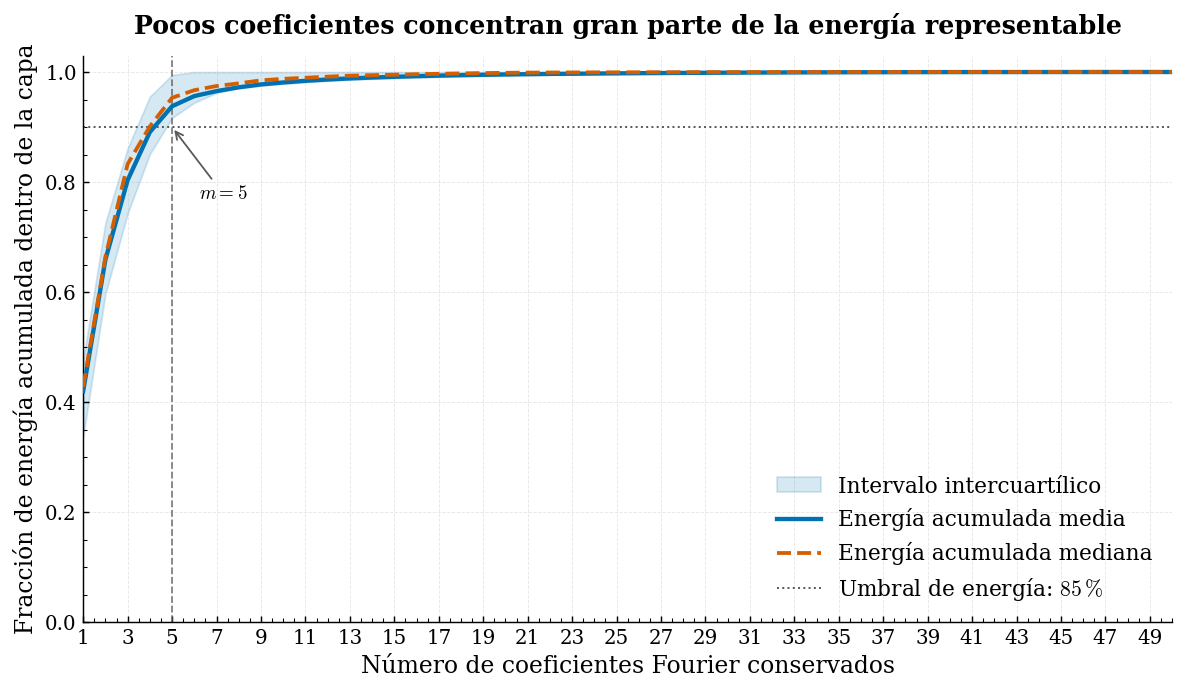

In [66]:
# Mediana y cuartiles de la energía acumulada dentro de la capa
mediana_energia_capa = np.median(
    energia_acumulada_capa,
    axis=0
)

p25_energia_capa = np.percentile(
    energia_acumulada_capa,
    25,
    axis=0
)

p75_energia_capa = np.percentile(
    energia_acumulada_capa,
    75,
    axis=0
)

# La energía acumulada empieza en m = 1
m_coeficientes = np.arange(
    1,
    N_COEFICIENTES + 1
)

fig, ax = plt.subplots(
    figsize=(9.0, 5.2),
    layout="constrained"
)

ax.fill_between(
    m_coeficientes,
    p25_energia_capa,
    p75_energia_capa,
    color=COLOR_FOURIER,
    alpha=0.16,
    label="Intervalo intercuartílico",
    zorder=1
)

ax.plot(
    m_coeficientes,
    energia_media_acumulada_capa,
    color=COLOR_FOURIER,
    linewidth=2.4,
    label="Energía acumulada media",
    zorder=3
)

ax.plot(
    m_coeficientes,
    mediana_energia_capa,
    color=COLOR_ALEATORIA,
    linewidth=2.1,
    linestyle="--",
    label="Energía acumulada mediana",
    zorder=3
)

ax.axhline(
    UMBRAL_ENERGIA,
    color=COLOR_REFERENCIA,
    linewidth=1.1,
    linestyle=":",
    label=r"Umbral de energía: $85\,\%$",
    zorder=2
)

if m_85_promedio_capa is not None:
    ax.axvline(
        m_85_promedio_capa,
        color=COLOR_REFERENCIA,
        linewidth=1.0,
        linestyle="--",
        alpha=0.75,
        zorder=2
    )

    ax.annotate(
        rf"$m={m_85_promedio_capa}$",
        xy=(
            m_85_promedio_capa,
            UMBRAL_ENERGIA
        ),
        xytext=(15, -40),
        textcoords="offset points",
        fontsize=10.5,
        arrowprops={
            "arrowstyle": "->",
            "color": COLOR_REFERENCIA,
            "linewidth": 1.0
        }
    )

ax.set_xlim(1, N_COEFICIENTES)
ax.set_ylim(0, 1.03)

ax.set_xticks(
    np.arange(
        1,
        N_COEFICIENTES + 1,
        2
    )
)

ax.set_xlabel(
    "Número de coeficientes Fourier conservados"
)

ax.set_ylabel(
    "Fracción de energía acumulada dentro de la capa"
)

ax.set_title(
    "Pocos coeficientes concentran gran parte de la energía representable",
    pad=12
)

ax.grid(
    True,
    which="major",
    color="#B0B0B0",
    linestyle="--",
    linewidth=0.5,
    alpha=0.30,
    zorder=0
)

ax.legend(
    loc="lower right",
    frameon=False
)

plt.show()

**Figura 8. Energía acumulada dentro de la capa Fourier.**

Los coeficientes se ordenan por energía para cada señal. En promedio, $m=4$
alcanza el $85\,\%$ de la energía **representada por los 30 coeficientes**. No
significa necesariamente el $85\,\%$ de la energía total, pues la capa completa
captura en promedio el $75.57\,\%$ del conjunto.


# Conclusiones

- La capa Fourier $30\times256$ coincide con `np.fft` para una señal del
  régimen 2: error máximo $9.59\times10^{-14}$.
- La energía media del conjunto es $0.715$, una referencia de su escala global.
- El error relativo medio bajó de $0.1$ en las iteraciones 976 (Fourier) y 559
  (aleatoria). En el régimen foco ocurrió en 1149 y 639, respectivamente.
- La aleatoria terminó con menor error medio global ($0.0333$ frente a $0.0602$).
  Fourier tuvo más dificultad en el régimen 2 por la fuga espectral y por las
  frecuencias superiores o no alineadas con $k=1,\ldots,15$.
- Cuatro coeficientes conservan en promedio el $85\,\%$ de la energía contenida
  en la capa. Con los 30 coeficientes, el error medio sigue en $0.3179$ porque
  la base no representa todo el espectro de las señales.

La comparación describe reconstrucción sobre las señales entrenadas. No se
interpreta como desempeño de validación, porque la actividad no proporciona un
conjunto independiente.
